In [334]:
#import pylab as plt
import math
import numpy as np
import pandas as pd
from scipy import interpolate
from scipy.linalg import solve
import time
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

#start_time = time.time()

In [335]:
def display_grid(grid1, title1): # для отображения карт
  
  im=plt.imshow(
    grid1,
    cmap='jet',
    # extent=[0, 1630, 0, 1780],
    origin='lower',
    aspect='equal'
  )
  plt.colorbar(im)
  
  plt.title(title1)
  plt.show()
  
  return title1

In [336]:
def datareader(path):
    df = pd.read_csv(path,
        sep='\s+',
        header=None,
        skiprows=5,  # пропускаем первые 20 строк
        #names=['x', 'y', 'z_meters', 'column', 'row']
        names=['column', 'row', 'z_meters']
    )
    matrix = df.pivot(index='row', columns='column', values='z_meters')
    matr = np.array(matrix)
    return matr

In [339]:
poro_0 = datareader('maps_Costa/EDFM 1_Porosity_avg_vol_w.xyz') 
perm_0 = datareader('maps_Costa/EDFM 1_Permeability along X_avg_vol_w.xyz')
P_Init_map = datareader('maps_Costa/EDFM 1_Pressure_avg_vol_w.xyz')

In [338]:
def datareader_2(path):
    df = pd.read_csv(path,
        sep='\s+',
        header=None,
        skiprows=6,  # пропускаем первые 20 строк
        names=['x', 'y', 'z_meters', 'column', 'row']
        #names=['column', 'row', 'z_meters']
    )
    matrix = df.pivot(index='row', columns='column', values='z_meters')
    matr = np.array(matrix)
    return matr

# для починки апскейлинга смотри эти карты:

In [380]:
perm_integr = datareader_2('maps_Costa/nelson/permx_integr_1')
poro_integr = datareader_2('maps_Costa/nelson/poro_integr_1')

лучше всего ниже по коду будет присвоить:

In [387]:
# perm = perm_integr
# poro = poro_integr 

вот так они выглядят (неудивительно что ничего не считается)

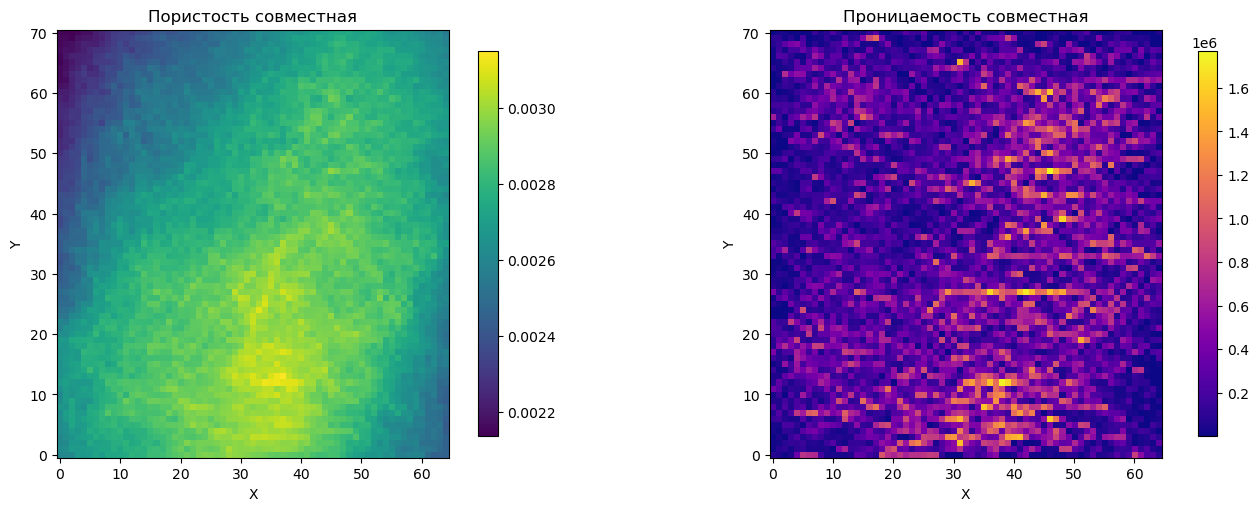

In [386]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

im1 = axes[0].imshow(
    poro_integr,
    cmap='viridis',
    origin='lower',
    aspect='equal',
    interpolation='nearest'
)
axes[0].set_title('Пористость совместная')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
fig.colorbar(im1, ax=axes[0], shrink=0.9)

im2 = axes[1].imshow(
    perm_integr,
    cmap='plasma',
    origin='lower',
    aspect='equal',
    interpolation='nearest'
)
axes[1].set_title('Проницаемость совместная')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
fig.colorbar(im2, ax=axes[1], shrink=0.9,)

plt.show()

# для развертки двойной среды бери уже отдельные карты сред матрицы и трещин:

In [ ]:
perm_matrix = datareader_2('maps_Costa/nelson/permx_matrix_2')
poro_matrix = datareader_2('maps_Costa/nelson/poro_matrix_2')
perm_dfn = datareader_2('maps_Costa/nelson/permx_X_dfn_2') # все с dfn в имени -- про трещины
permY_dfn = datareader_2('maps_Costa/nelson/permx_Y_dfn_2')
poro_dfn = datareader_2('maps_Costa/nelson/poro_dfn_2')
sigma = datareader_2('maps_Costa/nelson/sigma_2') # фактор связи трещин и матрицы

# так я соединяла карты матрицы и трещин, сверху трещины, снизу матрица
координаты ячейки скважины остались прежними

In [388]:
combined_vertical = np.vstack([perm_matrix, perm_dfn])

маску среды где фильтрация происходит в среде трещин решили брать по ненулевым значениям $\sigma$-фактора

$\sigma$-фактор участвует в расчете проводимости между трещиной и матрицей

In [389]:
mask = sigma > 0

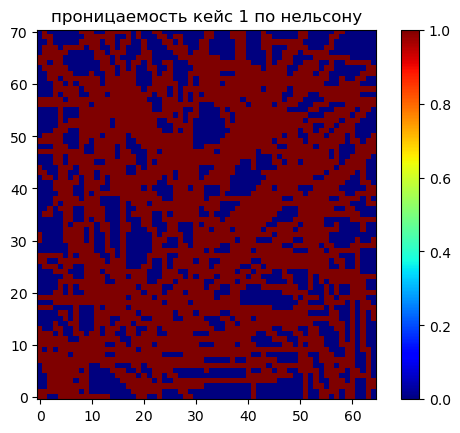

'проницаемость кейс 1 по нельсону'

In [390]:
display_grid(mask,'проницаемость кейс 1 по нельсону')

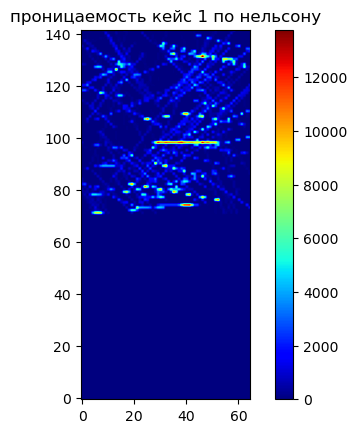

'проницаемость кейс 1 по нельсону'

In [368]:
display_grid(combined_vertical,'проницаемость кейс 1 по нельсону')

$N*M$ - размер одной карты, N,M = heff.shape (или poro.shape, не важно)

$K < N*M$ - число активных ячеек в маске (куда попали трещины, $\sigma>0$)

$D*D$ - размер матрицы для расчета PSS в одной среде, здесь  $D = N*M$  

в двойной среде $Z = (A + N*M)$ , $Z*Z$ неизвестных в новой системе для расчета PSS. *(напоминалка)

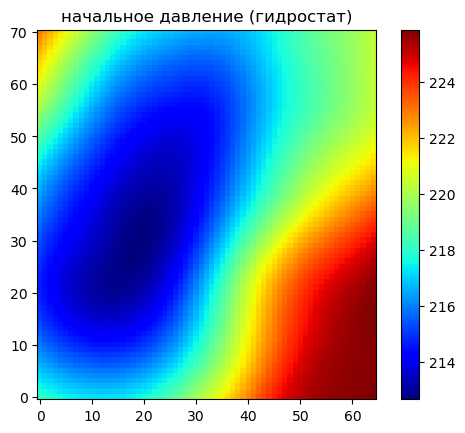

'начальное давление (гидростат)'

In [392]:
display_grid(P_Init_map,'начальное давление (гидростат)') # на него делали поправку поэтому картинки стали красивее и к расчету тнава ближе

# далее выбирай что раскомментировать

In [ ]:
# heff = datareader_2('maps_Costa/map_heff')
heff = datareader_2('maps_Costa/heff')
# poro = poro_0 # это старые карты на которых всё работало
# perm = perm_0

# чтобы посмотреть где возникают уроды в углах, нужны карты:

# perm = perm_integr # это новые карты на которых ничего не сработало
# poro = poro_integr 

In [329]:
#Ввод параметров пласта
N=heff.shape[0]
#без вычитания крайнего значения
M=heff.shape[1]
#без вычитания крайнего значения

RN=250*heff.shape[0] #[м] размер расчетной области (ширина прямоугольника по Y)
RM = 250*heff.shape[1] #[м] размер расчетной области (длина прямоугольника по Х)
dx =250  #[м] шаг сетки по пространству, длина и ширина квадратной ячейки

# poro = np.random.uniform(0.2, 0.2, (N+1,N+1)) # ввод сетки пористости
# permx= np.random.uniform(100, 100, (N+1,N+1)) # ввод сетки проницаемости
# Heff= np.random.uniform(10, 10, (N+1,M+1)) # ввод сетки эффективной мощности пласта

# fault=np.zeros((N+1,N+1))

#display_grid(poro, 'poro')
#display_grid(permx, 'permx')

# ввод PVT данных
Mu = 0.3125 # viscousity [cp]
# Mu = 1 # проверю влияние вязкости на поле theta
Ct =0.0001 # compress [1/bar]
Bo=1.5 # Объемный коэф.
#---------=====-------------
ct=Ct#/100000 # compress [1/Pa]
mu=Mu#/1000 # viscousity [Pa*sec]

rw=0.1524 #[м] радиус скв.
qw=100 #[m3/day] дебит нефти
BHP=170 # [bar]
S=0 #Скин-фактор
PInit=217 # [bar] Начальное пластовое давление
T_max=3600*24*100  # [сек] период расчета
dt=3600*24 # [сек] шаг по времени

N_tau_mesh_ravn=100 #количество элементов в сетке по tau
I_well= int(N/2) # Индекс по по горизонтали задающий положение скв.
J_well= int(M/2) # Индекс по по горизонтали задающий положение скв.
#Well_Index = 1 #Индекс продуктивности скважины
cDarcy=0.008527 #6.28
# Well_Index = 1/ (1/mu * cDarcy * permx[I_well, J_well] * Heff[I_well, J_well] ) * (np.log(0.14* np.sqrt(dx_1*dx_1 + dx_1*dx_1)/rw) - 0.5) 
# a = 10/ ct/ np.sum(dx_1 * dx_1 * Heff * poros)

In [330]:
a = 10/ ct/ np.sum(dx * dx * heff * poro)

In [ ]:
Well_Index = 1/ (1/mu * cDarcy * perm[I_well, J_well] * heff[I_well, J_well] ) * (np.log(0.14* np.sqrt(dx*dx + dx*dx)/rw) - 0.5) 

In [331]:
V_res = np.sum(dx * dx * heff * poro)

In [332]:
Well_Index, V_res, a

(1.1076375235283357e-05, 44852371.00133856, 0.0022295365388156547)

# финт ушами чтобы старую матрицу собрать и решить СЛАУ

In [230]:
N,M = heff.shape
N = N-1
M = M-1 

# старая матрица слау с ошибкой в углах

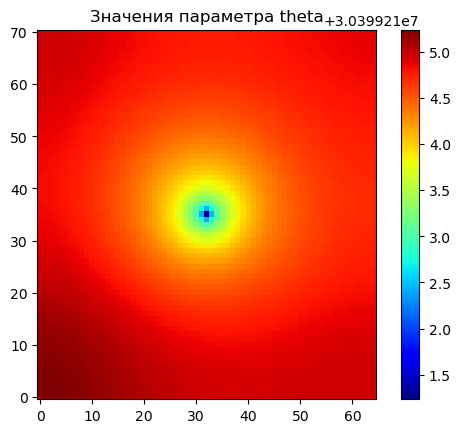

30399214.6940433


In [231]:
Perm_f=perm_0.flatten()
Poro_f=poro_0.flatten()
Heff_f=heff.flatten()
  #заглушка (см выше)

D=(N+1)*(M+1) # вопрос: а ячеек столько??
A=np.zeros((D,D)) # а размерность такая???
b=np.zeros(shape=(D))
well_cell_idx = I_well * poro.shape[1] + J_well
#perm=perm/(10**15)

lam = Perm_f / Perm_f / mu # в статье лямбда в сантипуазах в -1 степени
def build_system_matrix(N, M, Perm_f, Heff_f, cDarcy, well_cell_idx):
    D = (N+1)*(M+1)
    A = np.zeros((D, D))
    
    # Вычисляем lambda для всех ячеек сразу
    #lam = perm / perm / mu
    lam = 1/mu
    
    # Создаем маски для разных типов ячеек
    inner_cells = np.arange(M+2, N*(M+1))
    first_row = np.arange(1, M)
    last_row = np.arange(N*(M+1)+1, (M+1)*(N+1)-1)
    
    # Функция для вычисления коэффициентов
    def calc_coeffs(i, j):
        return lam * cDarcy * (Heff_f[i] + Heff_f[j]) / ((1/Perm_f[i]) + (1/Perm_f[j]))
    
    # Заполняем внутренние ячейки
    for i in inner_cells:
        A[i, i] = (calc_coeffs(i, i-1) + calc_coeffs(i, i+1) + 
                   calc_coeffs(i, i-M-1) + calc_coeffs(i, i+M+1))
        A[i, i-1] = -calc_coeffs(i, i-1)
        A[i, i+1] = -calc_coeffs(i, i+1)
        A[i, i-M-1] = -calc_coeffs(i, i-M-1)
        A[i, i+M+1] = -calc_coeffs(i, i+M+1)
    
    # Заполняем первую строку
    i = 0
    A[i, i] = calc_coeffs(i, i+1) + calc_coeffs(i, i+M+1)
    A[i, i+1] = -calc_coeffs(i, i+1)
    A[i, i+M+1] = -calc_coeffs(i, i+M+1)
    
    # Заполняем промежуточные ячейки первой строки
    for i in first_row:
        A[i, i] = (calc_coeffs(i, i-1) + calc_coeffs(i, i+1) + 
                   calc_coeffs(i, i+M+1))
        A[i, i-1] = -calc_coeffs(i, i-1)
        A[i, i+1] = -calc_coeffs(i, i+1)
        A[i, i+M+1] = -calc_coeffs(i, i+M+1)
    
    # Заполняем последнюю ячейку первой строки
    i = M
    A[i, i] = calc_coeffs(i, i-1) + calc_coeffs(i, i+M+1)
    A[i, i-1] = -calc_coeffs(i, i-1)
    A[i, i+M+1] = -calc_coeffs(i, i+M+1)
    
    # Заполняем левую границу
    for k in range(1, N):
        i = k*(M+1)
        A[i, i] = (calc_coeffs(i, i-M-1) + calc_coeffs(i, i+1) + 
                   calc_coeffs(i, i+M+1))
        A[i, i-M-1] = -calc_coeffs(i, i-M-1)
        A[i, i+1] = -calc_coeffs(i, i+1)
        A[i, i+M+1] = -calc_coeffs(i, i+M+1)
        A[i, i-1] = 0
    
    # Заполняем правую границу
    for k in range(1, N):
        i = k*(M+1)-1
        A[i, i] = (calc_coeffs(i, i-M-1) + calc_coeffs(i, i-1) + 
                   calc_coeffs(i, i+M+1))
        A[i, i-M-1] = -calc_coeffs(i, i-M-1)
        A[i, i-1] = -calc_coeffs(i, i-1)
        A[i, i+M+1] = -calc_coeffs(i, i+M+1)
        A[i, i+1] = 0
    
    # Заполняем последнюю строку
    i = N*(M+1)
    A[i, i] = calc_coeffs(i, i-M-1) + calc_coeffs(i, i+1)
    A[i, i-M-1] = -calc_coeffs(i, i-M-1)
    A[i, i+1] = -calc_coeffs(i, i+1)
    
    i = (M+1)*(N+1)-1
    A[i, i] = calc_coeffs(i, i-M-1) + calc_coeffs(i, i-1)
    A[i, i-M-1] = -calc_coeffs(i, i-M-1)
    A[i, i-1] = -calc_coeffs(i, i-1)
    
    # Заполняем промежуточные ячейки последней строки
    for i in last_row:
        A[i, i] = (calc_coeffs(i, i-1) + calc_coeffs(i, i+1) + 
                   calc_coeffs(i, i-M-1))
        A[i, i-1] = -calc_coeffs(i, i-1)
        A[i, i+1] = -calc_coeffs(i, i+1)
        A[i, i-M-1] = -calc_coeffs(i, i-M-1)
    
    # Корректируем коэффициенты для скважинной ячейки
    i = well_cell_idx
    A[i, i] = (lam * Well_Index + calc_coeffs(i, i-1) + calc_coeffs(i, i+1) + 
               calc_coeffs(i, i-M-1) + calc_coeffs(i, i+M+1))
    A[i, i-1] = -calc_coeffs(i, i-1)
    A[i, i+1] = -calc_coeffs(i, i+1)
    A[i, i-M-1] = -calc_coeffs(i, i-M-1)
    A[i, i+M+1] = -calc_coeffs(i, i+M+1)
    
    return A

# Создаем правую часть системы
b = ct * dx * dx * Heff_f * Poro_f * a
B = b.reshape(-1, 1)

# Решаем систему
A = build_system_matrix(N, M, Perm_f, Heff_f, cDarcy, well_cell_idx)
x = solve(A, B)

# Преобразуем решение в нужную форму
Pss = np.reshape(x, (N+1, M+1))
theta_0 = Pss
display_grid(theta_0, 'Значения параметра theta')
print(np.mean(theta_0))

# новая матрица без ошибок в углах

In [259]:
import numpy as np
from scipy.sparse import coo_matrix, csr_matrix
from scipy.sparse.linalg import spsolve


def build_system_matrix(
    perm,
    heff,
    mu,
    cDarcy,
    well_rc=None,
    well_index=0.0,
    eps=1e-30,
):
    """
    Сборка матрицы СЛАУ для 2D-сетки с no-flow внешними границами.

    Порядок flatten:
        idx = row * ncols + col

    Параметры:
        perm      : 2D array, проницаемость
        heff      : 2D array, эффективная толщина
        mu        : вязкость
        cDarcy    : коэффициент перевода единиц
        well_rc   : tuple(row, col) для скважинной ячейки или None
        well_index: Well Index
        eps       : малый порог для защиты от деления на ноль

    Возвращает:
        A : scipy.sparse.csr_matrix
    """

    perm = np.asarray(perm, dtype=float)
    heff = np.asarray(heff, dtype=float)

    if perm.shape != heff.shape:
        raise ValueError(f"perm.shape={perm.shape} не совпадает с heff.shape={heff.shape}")

    nrows, ncols = heff.shape
    D = nrows * ncols

    def idx(row, col):
        return row * ncols + col

    def transmissibility(row1, col1, row2, col2):
        """
        Твой исходный коэффициент:

            T_ij = cDarcy / mu * (h_i + h_j) / (1/k_i + 1/k_j)

        Это сохраняет старую физическую формулу, но убирает ошибки индексации.
        """

        k1 = perm[row1, col1]
        k2 = perm[row2, col2]
        h1 = heff[row1, col1]
        h2 = heff[row2, col2]

        if not np.isfinite(k1) or not np.isfinite(k2):
            return 0.0

        if not np.isfinite(h1) or not np.isfinite(h2):
            return 0.0

        if k1 <= eps or k2 <= eps or h1 <= eps or h2 <= eps:
            return 0.0

        return (cDarcy / mu) * (h1 + h2) / ((1.0 / k1) + (1.0 / k2))

    rows = []
    cols = []
    data = []

    def add_value(i, j, value):
        rows.append(i)
        cols.append(j)
        data.append(value)

    def add_connection(cell_i, cell_j, T):
        """
        Для связи i-j добавляем вклад:

            A[i, i] += T
            A[j, j] += T
            A[i, j] -= T
            A[j, i] -= T

        Так симметрия гарантирована конструктивно.
        """

        if T == 0.0:
            return

        add_value(cell_i, cell_i, T)
        add_value(cell_j, cell_j, T)
        add_value(cell_i, cell_j, -T)
        add_value(cell_j, cell_i, -T)

    for row in range(nrows):
        for col in range(ncols):
            i = idx(row, col)

            # Связь вправо
            if col + 1 < ncols:
                j = idx(row, col + 1)
                T = transmissibility(row, col, row, col + 1)
                add_connection(i, j, T)

            # Связь вниз
            if row + 1 < nrows:
                j = idx(row + 1, col)
                T = transmissibility(row, col, row + 1, col)
                add_connection(i, j, T)

    # Скважинный член
    if well_rc is not None:
        well_row, well_col = well_rc

        if not (0 <= well_row < nrows and 0 <= well_col < ncols):
            raise ValueError(
                f"well_rc={well_rc} вне сетки shape={heff.shape}"
            )

        well_cell_idx = idx(well_row, well_col)
        add_value(well_cell_idx, well_cell_idx, well_index / mu)

    A = coo_matrix((data, (rows, cols)), shape=(D, D)).tocsr()

    return A

# опять же перед вызовом перезаписываем N,M

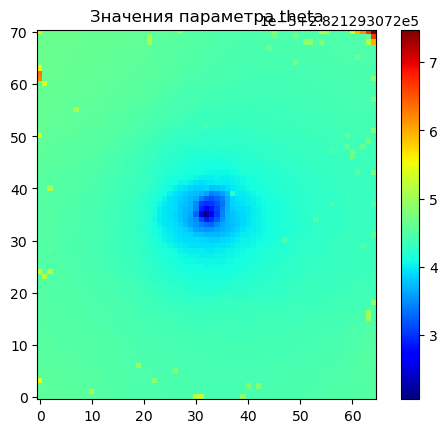

282129.30724376533


In [ ]:
N, M = heff.shape

A = build_system_matrix(
    perm=perm,
    heff=heff,
    mu=mu,
    cDarcy=cDarcy,
    well_rc=(I_well, J_well),
    well_index=Well_Index,
)

Perm_f = perm.reshape(-1, order="C")
Poro_f = poro.reshape(-1, order="C")
Heff_f = heff.reshape(-1, order="C")

b = ct * dx * dx * Heff_f * Poro_f * a

x = spsolve(A, b)

theta = x.reshape(heff.shape, order="C")

display_grid(theta, "Значения параметра theta")
print(np.mean(theta))

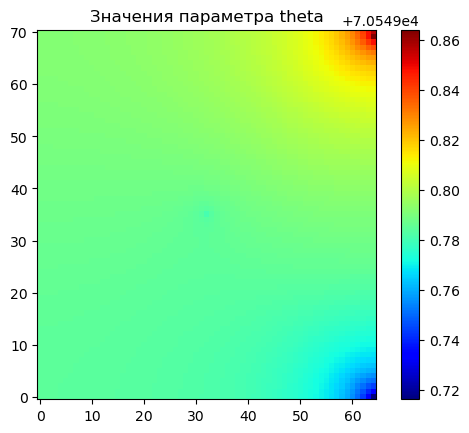

'Значения параметра theta'

In [236]:
display_grid(theta_0 - theta_1, "Значения параметра theta")

проверяла совпадают ли координаты минимума в разных картах заодно неплохо проверять какой задавали индекс у ячейки скважины

такой: (35,32)

In [237]:
idx = np.argmin(theta_0)
coords = np.unravel_index(idx, theta_0.shape)

print(coords)      # (1, 1)
print(theta_0[coords])   # 1

(35, 32)
30399211.23344547


# дальше будет ряд проверок можно это пропустить

In [240]:
from scipy.sparse.linalg import norm as sparse_norm
from scipy.sparse.csgraph import connected_components

nrows, ncols = heff.shape
well_cell_idx = I_well * ncols + J_well

# 1. Симметрия
sym_err = sparse_norm(A - A.T) / sparse_norm(A)
print("sym_err =", sym_err)

# 2. Суммы строк
row_sum = np.asarray(A.sum(axis=1)).ravel()
print("row_sum min/max:", row_sum.min(), row_sum.max())
print("row_sum well:", row_sum[well_cell_idx])

# 3. Связность
G = A.copy().tocsr()
G.setdiag(0)
G.eliminate_zeros()
G.data = np.ones_like(G.data)

ncomp, labels = connected_components(G, directed=False)

print("components:", ncomp)
print("component sizes:", np.bincount(labels))
print("well component:", labels[well_cell_idx])
print("cells outside well component:", np.sum(labels != labels[well_cell_idx]))

# 4. Проверка плохих несоседних связей
rows, cols = A.nonzero()

bad_links = []

for i, j in zip(rows, cols):
    if i == j:
        continue

    ri, ci = divmod(i, ncols)
    rj, cj = divmod(j, ncols)

    if abs(ri - rj) + abs(ci - cj) != 1:
        bad_links.append((i, j, (ri, ci), (rj, cj), A[i, j]))

print("bad non-neighbor links:", len(bad_links))

for link in bad_links[:20]:
    print(link)

sym_err = 0.0
row_sum min/max: -2.8421709430404007e-13 3.544440070868404e-05
row_sum well: 3.544440070868404e-05
components: 1
component sizes: [4615]
well component: 0
cells outside well component: 0
bad non-neighbor links: 0


In [262]:
A = A.toarray()
print("shape:", A.shape)
print("rank:", np.linalg.matrix_rank(A))
print("cond:", np.linalg.cond(A))

shape: (4615, 4615)
rank: 4614
cond: 1699513026624961.5


In [ ]:
Perm_f=perm_1.flatten()
Poro_f=poro_1.flatten()
Heff_f=heff.flatten()
  #заглушка (см выше)

D=(N+1)*(M+1) # вопрос: а ячеек столько??
A=np.zeros((D,D)) # а размерность такая???
b=np.zeros(shape=(D))
well_cell_idx = I_well * poro.shape[1] + J_well

# A = build_system_matrix(N, M, Perm_f, Heff_f, cDarcy, well_cell_idx)

print("shape:", A.shape)
print("rank:", np.linalg.matrix_rank(A))
print("cond:", np.linalg.cond(A))

shape: (4615, 4615)
rank: 4614
cond: 8458023117271071.0


In [263]:
D = A.shape[0]

row_sum = np.asarray(A.sum(axis=1)).ravel()
alpha = row_sum[well_cell_idx]

print("well alpha =", alpha)
print("alpha / D =", alpha / D)

ones = np.ones(D)
rayleigh_const = ones @ (A @ ones) / (ones @ ones)

print("Rayleigh quotient for constant mode =", rayleigh_const)

well alpha = 3.544453647918999e-05
alpha / D = 7.68028959462405e-09
Rayleigh quotient for constant mode = 7.680360421031266e-09


In [241]:
E = A - A.T
absE = np.abs(E)
absE = absE.toarray()

rows, cols = np.where(absE > 1e-12)

print("number of asymmetric entries:", len(rows))
print("max asymmetry:", absE.max())

for n in range(min(20, len(rows))):
    i, j = rows[n], cols[n]
    print(i, j, A[i, j], A[j, i], "diff =", A[i, j] - A[j, i])

number of asymmetric entries: 0
max asymmetry: 0.0


In [190]:
ncols = M + 1

def rc(i):
    return i // ncols, i % ncols

for n in range(min(50, len(rows))):
    i, j = rows[n], cols[n]
    print(i, rc(i), "<->", j, rc(j), A[i, j], A[j, i])

64 (0, 64) <-> 4614 (70, 64) -104774.68683966498 0.0
4549 (69, 64) <-> 4550 (70, 0) -43.925087406172565 0.0
4550 (70, 0) <-> 4549 (69, 64) 0.0 -43.925087406172565
4614 (70, 64) <-> 64 (0, 64) 0.0 -104774.68683966498


In [194]:
sym_err = np.linalg.norm(A - A.T) / np.linalg.norm(A)
print('sym_err = ',sym_err)

sym_err =  0.000943182743571044


In [195]:
s = np.linalg.svd(A, compute_uv=False)
print(s[-10:])
print("cond:", s[0] / s[-1])

[2.25001841e+02 2.13219879e+02 2.07437659e+02 2.04090893e+02
 1.98180544e+02 1.59568327e+02 1.41746863e+02 1.34641088e+02
 9.14610140e+01 1.55271583e-09]
cond: 8458023117271071.0


In [173]:
A = build_system_matrix(N, M, Perm_f, Heff_f, cDarcy, well_cell_idx)

print("shape:", A.shape)
print("rank:", np.linalg.matrix_rank(A))
print("cond:", np.linalg.cond(A))

shape: (4615, 4615)
rank: 4615
cond: 359669148269.4902


In [177]:
row_sum = A.sum(axis=1)
print(row_sum.min(), row_sum.max())
print(row_sum[well_cell_idx])

-2.8421709430404007e-13 3.544440082237088e-05
3.544440082237088e-05


In [178]:
print("perm min/max:", np.nanmin(Perm_f), np.nanmax(Perm_f))
print("heff min/max:", np.nanmin(Heff_f), np.nanmax(Heff_f))
print("zero perm:", np.sum(Perm_f <= 0))
print("zero heff:", np.sum(Heff_f <= 0))

perm min/max: 46.940425872802734 312.8123168945313
heff min/max: 45.93866 66.223145
zero perm: 0
zero heff: 0


In [179]:
sym_err = np.linalg.norm(A - A.T) / np.linalg.norm(A)
print(sym_err)

0.003865949128022319


In [180]:
s = np.linalg.svd(A, compute_uv=False)
print(s[-10:])
print("cond:", s[0] / s[-1])

[3.16465636e+00 2.45719807e+00 2.12512771e+00 2.06350317e+00
 1.67945865e+00 1.20021596e+00 9.69591904e-01 5.35271161e-01
 3.84946398e-01 7.49131223e-09]
cond: 359669148269.4902


In [184]:
from scipy.sparse import csr_matrix

In [244]:
from scipy.sparse.csgraph import connected_components

A_csr = csr_matrix(A)
G = A_csr.copy().tocsr()
G.setdiag(0)
G.data = np.ones_like(G.data)

ncomp, labels = connected_components(G, directed=False)

print("components:", ncomp)
print("component sizes:", np.bincount(labels))
print("well component:", labels[well_cell_idx])
print("cells outside well component:", np.sum(labels != labels[well_cell_idx]))

components: 1
component sizes: [4615]
well component: 0
cells outside well component: 0


In [158]:
theta.max(), theta.min()

(315135.47171927616, 315135.4716639158)

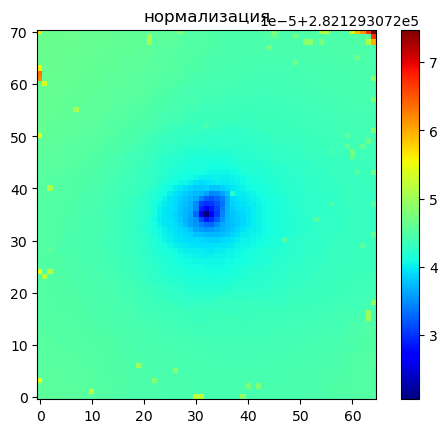

'нормализация'

In [264]:
theta_normalised = (theta - theta.min()) / (theta.max() - theta.min())
display_grid(theta,'нормализация')

In [265]:
theta.max(), theta.min()

(282129.3072747606, 282129.3072206148)

In [160]:
A = build_system_matrix(N, M, Perm_f, Heff_f, cDarcy, well_cell_idx=1596)
b = ct * dx * dx * Heff_f * Poro_f * a

x = solve(A, b)
Pss = x.reshape(N+1, M+1)

theta_abs = Pss
theta_rel = Pss - x[1596]

print("abs min/max:", theta_abs.min(), theta_abs.max())
print("rel min/max:", theta_rel.min(), theta_rel.max())
print("theta_well abs:", x[1596])
print("theta_well rel:", theta_rel.ravel()[1596])

row_sums = A.sum(axis=1)
print("row sums:", row_sums.min(), row_sums.max(), row_sums[1596])

res = A @ x - b
print("relative residual:", np.linalg.norm(res) / np.linalg.norm(b))

abs min/max: 320955.4625219228 320955.462570101
rel min/max: 0.0 4.817824810743332e-05
theta_well abs: 320955.4625219228
theta_well rel: 0.0
row sums: -9.313225746154785e-10 3.5444332752376795e-05 3.5444332752376795e-05
relative residual: 0.062312942075057394


C:\Users\NovgorodovaAN\AppData\Local\Temp\ipykernel_24216\2681555156.py:4: LinAlgWarning: Ill-conditioned matrix (rcond=1.60246e-18): result may not be accurate.
  x = solve(A, b)


In [79]:
i, j = np.unravel_index(well_cell_idx, (N+1, M+1))
i,j

(35, 32)

In [80]:
np.max(theta)-np.min(theta), np.mean(theta)

(0.037284367960580767, 135.95943168937305)

единицы измерения?

# проверки кончились, можно лечить апскейлинг! последний интервал оторван от предпоследнего, они не связаны гидродинамически, это большая проблема

In [246]:
from collections import deque


def neighbors4(i, j, N, M): 
    for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]: 
        ni, nj = i + di, j + dj 
        if 0 <= ni <= N and 0 <= nj <= M: 
            yield ni, nj

def dilate_mask(mask, N, M, radius):
    """Создает расширенную маску вокруг принятых ячеек"""
    dilated = np.zeros_like(mask)
    for i in range(N+1):
        for j in range(M+1):
            if mask[i,j] > 0:
                # Создаем окно вокруг текущей ячейки
                i_start = max(0, i-radius)
                i_end = min(N+1, i+radius+1)
                j_start = max(0, j-radius)
                j_end = min(M+1, j+radius+1)
                
                # Проверяем условие |k| + |s| < radius+1 для каждой ячейки в окне
                for k in range(i_start, i_end):
                    for s in range(j_start, j_end):
                        if abs(k-i) + abs(s-j) < radius+1:
                            dilated[k,s] = 1
    return dilated

def calculate_threshold(theta_discret, theta_accepted, theta_dilation, Heff, poros, dx_1):
    """Вычисляет пороговое значение для текущего шага"""
    # Создаем маску для необработанных ячеек в области дилатации
    mask = (theta_dilation == 1) & (theta_accepted == 0)
    
    # Вычисляем числитель и знаменатель порогового значения
    numerator = np.sum(theta_discret[mask] * Heff[mask] * poros[mask] * dx_1**2)
    denominator = np.sum(Heff[mask] * poros[mask] * dx_1**2)
    
    return numerator / denominator if denominator > 0 else 0

def connected_components(mask):
    """
    Возвращает список 4-связных компонент для булевой маски.
    Каждая компонента — список пар (i, j).
    """
    N, M = mask.shape[0] - 1, mask.shape[1] - 1
    visited = np.zeros_like(mask, dtype=bool)
    comps = []

    for i in range(N + 1):
        for j in range(M + 1):
            if mask[i, j] and not visited[i, j]:
                comp = []
                q = deque([(i, j)])
                visited[i, j] = True

                while q:
                    ci, cj = q.popleft()
                    comp.append((ci, cj))

                    for ni, nj in neighbors4(ci, cj, N, M):
                        if mask[ni, nj] and not visited[ni, nj]:
                            visited[ni, nj] = True
                            q.append((ni, nj))

                comps.append(comp)

    return comps


def process_step(theta_discret, theta_accepted, theta_dilation, threshold, Heff, poros, dx_1):
    """
    Один шаг алгоритма:
    принимает ячейки внутри области dilation, у которых theta_discret < threshold,
    и присваивает им текущее пороговое значение.
    """
    mask = (
        (theta_dilation == 1) &
        (theta_accepted == 0) &
        (theta_discret < threshold)
    )

    theta_discret[mask] = threshold
    theta_accepted[mask] = 1

    return theta_discret, theta_accepted


def cleanup_newly_accepted(theta_discret, theta_accepted, theta_accepted_prev,
                           Heff, poros, dx_1,
                           min_cells=2, min_pv=0.0):
    """
    Удаляет нежелательные новые компоненты:
    - слишком маленькие по числу ячеек,
    - слишком маленькие по pore volume,
    - не имеющие контакта с предыдущим accepted-set.
    """
    def component_pv(comp):
        return sum(Heff[i, j] * poros[i, j] * dx_1**2 for i, j in comp)

    def touches_old_accepted(comp):
        N, M = theta_accepted_prev.shape[0] - 1, theta_accepted_prev.shape[1] - 1
        for i, j in comp:
            for ni, nj in neighbors4(i, j, N, M):
                if theta_accepted_prev[ni, nj] == 1:
                    return True
        return False

    new_cells = (theta_accepted == 1) & (theta_accepted_prev == 0)
    comps = connected_components(new_cells)

    keep_mask = np.zeros_like(theta_accepted, dtype=bool)

    for comp in comps:
        size = len(comp)
        pv = component_pv(comp)
        touches = touches_old_accepted(comp)

        keep = touches and (size >= min_cells or pv >= min_pv)

        if keep:
            for i, j in comp:
                keep_mask[i, j] = True

    reject_mask = new_cells & (~keep_mask)
    theta_accepted[reject_mask] = 0

    return theta_discret, theta_accepted


def enforce_global_connectivity(theta_accepted, well_i, well_j):
    """
    Оставляет только те accepted-ячейки, которые достижимы от скважины
    по 4-связности. Остальные считаются disconnected.
    """
    N, M = theta_accepted.shape[0] - 1, theta_accepted.shape[1] - 1

    visited = np.zeros_like(theta_accepted, dtype=bool)

    if theta_accepted[well_i, well_j] != 1:
        return theta_accepted, np.zeros_like(theta_accepted, dtype=bool)

    stack = [(well_i, well_j)]
    visited[well_i, well_j] = True

    while stack:
        i, j = stack.pop()

        for ni, nj in neighbors4(i, j, N, M):
            if theta_accepted[ni, nj] == 1 and not visited[ni, nj]:
                visited[ni, nj] = True
                stack.append((ni, nj))

    disconnected = (theta_accepted == 1) & (~visited)
    theta_accepted[disconnected] = 0

    return theta_accepted, disconnected

def remove_weak_cells(theta_accepted, well_i, well_j, min_neighbors=2):
    N, M = theta_accepted.shape[0] - 1, theta_accepted.shape[1] - 1
    to_remove = []

    for i in range(N + 1):
        for j in range(M + 1):
            if theta_accepted[i, j] == 1:
                # well-cell никогда не удаляем
                if i == well_i and j == well_j:
                    continue

                neighbors = sum(
                    theta_accepted[ni, nj]
                    for ni, nj in neighbors4(i, j, N, M)
                )

                if neighbors < min_neighbors:
                    to_remove.append((i, j))

    removed_mask = np.zeros_like(theta_accepted, dtype=bool)
    for i, j in to_remove:
        theta_accepted[i, j] = 0
        removed_mask[i, j] = True

    return theta_accepted, removed_mask

def main_algorithm(theta, Heff, poros, dx_1, N, M, well_i, well_j,
                   tolerance=0.005, radius=10,
                   min_cells=2, min_pv=0.0,
                   min_neighbors=1,
                   max_steps=300, stall_limit=5):

    theta_initial = theta.copy()
    theta_discret = theta.copy()

    theta_accepted = np.zeros((N + 1, M + 1), dtype=np.uint8)
    theta_accepted[well_i, well_j] = 1

    step = 0
    stall_counter = 0
    prev_accepted_count = np.sum(theta_accepted)

    while True:
        theta_dilation = dilate_mask(theta_accepted, N, M, radius=radius)

        threshold = calculate_threshold(
            theta_discret, theta_accepted, theta_dilation, Heff, poros, dx_1
        )

        # если расширяться больше некуда
        if threshold == 0:
            print("\nStopped: threshold became zero (no candidates left).")
            last_mask = (theta_accepted == 0)
            theta_discret[last_mask] = np.max(theta_discret[theta_accepted == 1]) if np.any(theta_accepted == 1) else 0
            break

        theta_accepted_prev = theta_accepted.copy()

        theta_discret, theta_accepted = process_step(
            theta_discret, theta_accepted, theta_dilation, threshold, Heff, poros, dx_1
        )

        theta_discret, theta_accepted = cleanup_newly_accepted(
            theta_discret=theta_discret,
            theta_accepted=theta_accepted,
            theta_accepted_prev=theta_accepted_prev,
            Heff=Heff,
            poros=poros,
            dx_1=dx_1,
            min_cells=min_cells,
            min_pv=min_pv
        )

        theta_accepted, disconnected_mask = enforce_global_connectivity(
            theta_accepted, well_i, well_j
        )
        theta_discret[disconnected_mask] = theta_initial[disconnected_mask]

        theta_accepted, weak_removed_mask = remove_weak_cells(
            theta_accepted,
            well_i=well_i,
            well_j=well_j,
            min_neighbors=min_neighbors
        )
        theta_discret[weak_removed_mask] = theta_initial[weak_removed_mask]

        # после удаления слабых ячеек ещё раз восстанавливаем глобальную связность
        theta_accepted, disconnected_mask_2 = enforce_global_connectivity(
            theta_accepted, well_i, well_j
        )
        theta_discret[disconnected_mask_2] = theta_initial[disconnected_mask_2]

        step += 1
        accepted_count = np.sum(theta_accepted)
        accepted_ratio = accepted_count / theta_accepted.size

        print(f"Step {step}, threshold: {threshold:.6f}, accepted cells: {accepted_ratio*100:.2f}%")

        if accepted_ratio >= (1.0 - tolerance):
            print(f"\nAlgorithm converged after {step} steps")
            print(f"Final acceptance ratio: {accepted_ratio*100:.2f}%")
            last_mask = (theta_accepted == 0)
            theta_discret[last_mask] = threshold
            break

        if accepted_count == prev_accepted_count:
            stall_counter += 1
        else:
            stall_counter = 0

        if stall_counter >= stall_limit:
            print(f"\nStopped: no progress for {stall_limit} iterations.")
            last_mask = (theta_accepted == 0)
            theta_discret[last_mask] = threshold
            break

        if step >= max_steps:
            print(f"\nStopped: reached max_steps={max_steps}")
            last_mask = (theta_accepted == 0)
            theta_discret[last_mask] = threshold
            break

        prev_accepted_count = accepted_count

    return theta_discret, theta_accepted, step

def neighboring_labels(comp, labels):
    """
    Возвращает словарь:
    {label_value: число контактов по границе}
    """
    N, M = labels.shape[0] - 1, labels.shape[1] - 1
    comp_set = set(comp)
    counts = {}

    for i, j in comp:
        for ni, nj in neighbors4(i, j, N, M):
            if (ni, nj) not in comp_set:
                lbl = labels[ni, nj]
                counts[lbl] = counts.get(lbl, 0) + 1

    return counts

def relabel_small_components(theta_discret, min_cells=2):
    """
    Убирает мелкие 4-связные компоненты каждого интервала.
    Компоненты меньше min_cells переназначаются в соседний интервал.
    """
    labels = theta_discret.copy()
    unique_vals = np.unique(labels)

    changed = False

    for val in unique_vals:
        mask = (labels == val)
        comps = connected_components(mask)

        for comp in comps:
            if len(comp) < min_cells:
                neighbor_counts = neighboring_labels(comp, labels)

                # убрать свой же label, если случайно попал
                neighbor_counts.pop(val, None)

                if len(neighbor_counts) == 0:
                    continue

                # выбрать соседа с максимальным числом контактов
                new_val = max(neighbor_counts.items(), key=lambda x: x[1])[0]

                for i, j in comp:
                    labels[i, j] = new_val

                changed = True

    return labels, changed

def final_interval_cleanup(theta_discret, min_cells=2, max_iter=20):
    labels = theta_discret.copy()

    for it in range(max_iter):
        labels, changed = relabel_small_components(labels, min_cells=min_cells)

        if not changed:
            print(f"Final cleanup converged after {it+1} iterations")
            return labels

    print("Warning: final cleanup reached max_iter")
    return labels

выше старая, ниже новая реализация.

In [247]:
theta_discret, theta_accepted, total_steps = main_algorithm(
    theta=theta,
    Heff=heff,
    poros=poro,
    dx_1=dx,
    N=N,
    M=M,
    well_i=8,
    well_j=56,
    radius=10,
    tolerance=0.005,
    min_cells=2,
    min_pv=0.0,
    min_neighbors=1,
    max_steps=300,
    stall_limit=5
)
theta_discret_clean = final_interval_cleanup(theta_discret, min_cells=2, max_iter=20)
display_grid(theta_discret_clean, "theta_discret_clean")

IndexError: boolean index did not match indexed array along dimension 0; dimension is 71 but corresponding boolean dimension is 72

In [248]:
theta_discret[I_well,J_well] == theta_discret[I_well+2, J_well+2]

False

новенькая версия 

In [372]:
N = N-1
M = M-1

In [373]:
from collections import deque

def create_well_mask(N, M, well_i, well_j):
    well_mask = np.zeros((N+1, M+1), dtype=bool)
    well_mask[well_i, well_j] = True
    return well_mask

def neighbors4(i, j, N, M): 
    """
    Смотрим соседей, если в границах - возвращаем
    """
    for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]: 
        ni, nj = i + di, j + dj 
        if 0 <= ni <= N and 0 <= nj <= M: 
            yield ni, nj

def dilate_mask(mask, N, M, radius):
    """Создает расширенную маску вокруг принятых ячеек"""
    dilated = np.zeros_like(mask)
    for i in range(N+1):
        for j in range(M+1):
            if mask[i,j] > 0:
                # Создаем окно вокруг текущей ячейки
                i_start = max(0, i-radius)
                i_end = min(N+1, i+radius+1)
                j_start = max(0, j-radius)
                j_end = min(M+1, j+radius+1)
                
                # Проверяем условие |k| + |s| < radius+1 для каждой ячейки в окне
                for k in range(i_start, i_end):
                    for s in range(j_start, j_end):
                        if abs(k-i) + abs(s-j) < radius+1:
                            dilated[k,s] = 1
    return dilated

def calculate_threshold(theta_discret, theta_accepted, theta_dilation, Heff, poros, dx_1):
    """Вычисляет пороговое значение для текущего шага"""
    # Создаем маску для необработанных ячеек в области дилатации
    mask = (theta_dilation == 1) & (theta_accepted == 0)
    
    # Вычисляем числитель и знаменатель порогового значения
    #тут на dx_1 можно сократить
    numerator = np.sum(theta_discret[mask] * Heff[mask] * poros[mask] * dx_1**2)
    denominator = np.sum(Heff[mask] * poros[mask] * dx_1**2)
    
    return numerator / denominator if denominator > 0 else 0

def connected_components(mask):
    """
    Возвращает список 4-связных компонент для булевой маски.
    Каждая компонента — список пар (i, j).
    """
    N, M = mask.shape[0] - 1, mask.shape[1] - 1
    visited = np.zeros_like(mask, dtype=bool)
    comps = []

    for i in range(N + 1):
        for j in range(M + 1):
            if mask[i, j] and not visited[i, j]:
                comp = []
                q = deque([(i, j)])
                visited[i, j] = True

                while q:
                    ci, cj = q.popleft()
                    comp.append((ci, cj))

                    for ni, nj in neighbors4(ci, cj, N, M):
                        if mask[ni, nj] and not visited[ni, nj]:
                            visited[ni, nj] = True
                            q.append((ni, nj))

                comps.append(comp)

    return comps


def process_step(theta_discret, theta_accepted, theta_dilation, threshold, Heff, poros, dx_1):
    """
    Один шаг алгоритма:
    принимает ячейки внутри области dilation, у которых theta_discret < threshold,
    и присваивает им текущее пороговое значение.
    """
    mask = (
        (theta_dilation == 1) &
        (theta_accepted == 0) &
        (theta_discret < threshold)
    )

    theta_discret[mask] = threshold
    theta_accepted[mask] = 1

    return theta_discret, theta_accepted


def cleanup_newly_accepted(theta_discret, theta_accepted, theta_accepted_prev,
                           Heff, poros, dx_1, well_mask,
                           min_cells=2, min_pv=0.0):
    """
    Удаляет нежелательные новые компоненты:
    - слишком маленькие по числу ячеек,
    - слишком маленькие по pore volume,
    - не имеющие контакта с предыдущим accepted-set.
    """
    def component_pv(comp):
        return sum(Heff[i, j] * poros[i, j] * dx_1**2 for i, j in comp)

    def touches_old_accepted(comp):
        N, M = theta_accepted_prev.shape[0] - 1, theta_accepted_prev.shape[1] - 1
        for i, j in comp:
            for ni, nj in neighbors4(i, j, N, M):
                if well_mask[ni, nj] or theta_accepted_prev[ni, nj] == 1:
                    return True
        return False

    new_cells = ((theta_accepted == 1) & (theta_accepted_prev == 0) & ~well_mask)
    comps = connected_components(new_cells)

    keep_mask = np.zeros_like(theta_accepted, dtype=bool)

    for comp in comps:
        size = len(comp)
        pv = component_pv(comp)
        touches = touches_old_accepted(comp)

        keep = touches and (size >= min_cells or pv >= min_pv)

        if keep:
            for i, j in comp:
                keep_mask[i, j] = True

    reject_mask = new_cells & (~keep_mask)
    theta_accepted[reject_mask] = 0

    return theta_discret, theta_accepted


def enforce_global_connectivity(theta_accepted, well_i, well_j):
    """
    Оставляет только те accepted-ячейки, которые достижимы от скважины
    по 4-связности. Остальные считаются disconnected.
    """
    N, M = theta_accepted.shape[0] - 1, theta_accepted.shape[1] - 1

    visited = np.zeros_like(theta_accepted, dtype=bool)

    if theta_accepted[well_i, well_j] != 1:
        return theta_accepted, np.zeros_like(theta_accepted, dtype=bool)

    stack = [(well_i, well_j)]
    visited[well_i, well_j] = True

    while stack:
        i, j = stack.pop()

        for ni, nj in neighbors4(i, j, N, M):
            if theta_accepted[ni, nj] == 1 and not visited[ni, nj]:
                visited[ni, nj] = True
                stack.append((ni, nj))

    disconnected = (theta_accepted == 1) & (~visited)
    theta_accepted[disconnected] = 0

    return theta_accepted, disconnected

def remove_weak_cells(theta_accepted, well_i, well_j, min_neighbors=2):
    N, M = theta_accepted.shape[0] - 1, theta_accepted.shape[1] - 1
    to_remove = []

    for i in range(N + 1):
        for j in range(M + 1):
            if theta_accepted[i, j] == 1:
                # well-cell никогда не удаляем
                if i == well_i and j == well_j:
                    continue

                neighbors = sum(
                    theta_accepted[ni, nj]
                    for ni, nj in neighbors4(i, j, N, M)
                )

                if neighbors < min_neighbors:
                    to_remove.append((i, j))

    removed_mask = np.zeros_like(theta_accepted, dtype=bool)
    for i, j in to_remove:
        theta_accepted[i, j] = 0
        removed_mask[i, j] = True

    return theta_accepted, removed_mask

def main_algorithm(theta, Heff, poros, dx_1, N, M, well_i, well_j,
                   tolerance=0.005, radius=10,
                   min_cells=2, min_pv=0.0,
                   min_neighbors=1,
                   max_steps=300, stall_limit=5):

    theta_initial = theta.copy()
    theta_discret = theta.copy()

    theta_accepted = np.zeros((N + 1, M + 1), dtype=np.uint8)
    theta_accepted[well_i, well_j] = 1
    well_mask = create_well_mask(N, M, well_i, well_j)

    step = 0
    stall_counter = 0
    prev_accepted_count = np.sum(theta_accepted)

    while True:
        theta_dilation = dilate_mask(theta_accepted, N, M, radius=radius)

        threshold = calculate_threshold(
            theta_discret, theta_accepted, theta_dilation, Heff, poros, dx_1
        )

        # если расширяться больше некуда
        if threshold == 0:
            print("\nStopped: threshold became zero (no candidates left).")
            last_mask = (theta_accepted == 0)
            theta_discret[last_mask] = np.max(theta_discret[theta_accepted == 1]) if np.any(theta_accepted == 1) else 0
            break

        theta_accepted_prev = theta_accepted.copy()

        theta_discret, theta_accepted = process_step(
            theta_discret, theta_accepted, theta_dilation, threshold, Heff, poros, dx_1
        )

        theta_discret, theta_accepted = cleanup_newly_accepted(
            theta_discret=theta_discret,
            theta_accepted=theta_accepted,
            theta_accepted_prev=theta_accepted_prev,
            Heff=Heff,
            poros=poros,
            dx_1=dx_1,
            well_mask=well_mask,
            min_cells=min_cells,
            min_pv=min_pv
        )

        theta_accepted, disconnected_mask = enforce_global_connectivity(
            theta_accepted, well_i, well_j
        )
        theta_discret[disconnected_mask] = theta_initial[disconnected_mask]

        theta_accepted, weak_removed_mask = remove_weak_cells(
            theta_accepted,
            well_i=well_i,
            well_j=well_j,
            min_neighbors=min_neighbors
        )
        theta_discret[weak_removed_mask] = theta_initial[weak_removed_mask]

        # после удаления слабых ячеек ещё раз восстанавливаем глобальную связность
        theta_accepted, disconnected_mask_2 = enforce_global_connectivity(
            theta_accepted, well_i, well_j
        )
        theta_discret[disconnected_mask_2] = theta_initial[disconnected_mask_2]

        step += 1
        accepted_count = np.sum(theta_accepted)
        accepted_ratio = accepted_count / theta_accepted.size

        print(f"Step {step}, threshold: {threshold:.6f}, accepted cells: {accepted_ratio*100:.2f}%")

        if accepted_ratio >= (1.0 - tolerance):
            print(f"\nAlgorithm converged after {step} steps")
            print(f"Final acceptance ratio: {accepted_ratio*100:.2f}%")
            last_mask = (theta_accepted == 0)
            theta_discret[last_mask] = threshold
            break

        if accepted_count == prev_accepted_count:
            stall_counter += 1
        else:
            stall_counter = 0

        if stall_counter >= stall_limit:
            print(f"\nStopped: no progress for {stall_limit} iterations.")
            last_mask = (theta_accepted == 0)
            theta_discret[last_mask] = threshold
            break

        if step >= max_steps:
            print(f"\nStopped: reached max_steps={max_steps}")
            last_mask = (theta_accepted == 0)
            theta_discret[last_mask] = threshold
            break

        prev_accepted_count = accepted_count

    return theta_discret, theta_accepted, step, well_mask

def neighboring_labels(comp, labels):
    """
    Возвращает словарь:
    {label_value: число контактов по границе}
    """
    N, M = labels.shape[0] - 1, labels.shape[1] - 1
    comp_set = set(comp)
    counts = {}

    for i, j in comp:
        for ni, nj in neighbors4(i, j, N, M):
            if (ni, nj) not in comp_set:
                lbl = labels[ni, nj]
                counts[lbl] = counts.get(lbl, 0) + 1

    return counts

def relabel_small_components(theta_discret, well_mask, min_cells=2):
    """
    Убирает мелкие 4-связные компоненты каждого интервала.
    Компоненты меньше min_cells переназначаются в соседний интервал.
    """
    labels = theta_discret.copy()
    unique_vals = np.unique(labels)

    changed = False

    for val in unique_vals:
        mask = (labels == val) & ~well_mask
        comps = connected_components(mask)

        for comp in comps:
            if len(comp) < min_cells:
                neighbor_counts = neighboring_labels(comp, labels)

                # убрать свой же label, если случайно попал
                neighbor_counts.pop(val, None)

                if len(neighbor_counts) == 0:
                    continue

                # выбрать соседа с максимальным числом контактов
                new_val = max(neighbor_counts.items(), key=lambda x: x[1])[0]

                for i, j in comp:
                    labels[i, j] = new_val

                changed = True

    return labels, changed

def final_interval_cleanup(theta_discret, well_mask, min_cells=4, max_iter=20):
    labels = theta_discret.copy()

    for it in range(max_iter):
        labels, changed = relabel_small_components(labels, well_mask, min_cells=min_cells)

        if not changed:
            print(f"Final cleanup converged after {it+1} iterations")
            return labels

    print("Warning: final cleanup reached max_iter")
    return labels

Step 1, threshold: 282129.307238, accepted cells: 1.65%
Step 2, threshold: 282129.307241, accepted cells: 6.24%
Step 3, threshold: 282129.307242, accepted cells: 13.95%
Step 4, threshold: 282129.307243, accepted cells: 25.63%
Step 5, threshold: 282129.307244, accepted cells: 40.17%
Step 6, threshold: 282129.307244, accepted cells: 56.88%
Step 7, threshold: 282129.307245, accepted cells: 73.35%
Step 8, threshold: 282129.307245, accepted cells: 87.24%
Step 9, threshold: 282129.307246, accepted cells: 94.89%
Step 10, threshold: 282129.307248, accepted cells: 98.35%
Step 11, threshold: 282129.307251, accepted cells: 99.46%
Step 12, threshold: 282129.307256, accepted cells: 99.78%

Algorithm converged after 12 steps
Final acceptance ratio: 99.78%
Final cleanup converged after 2 iterations


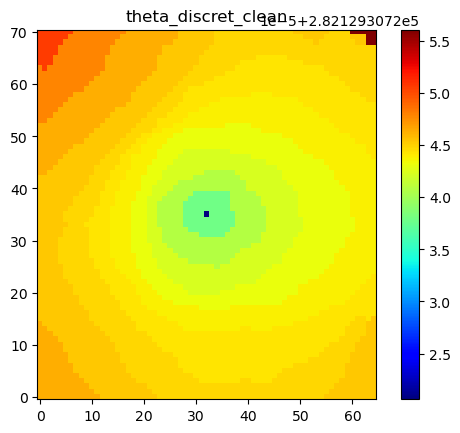

'theta_discret_clean'

In [375]:
# 1. Получить well_mask из main_algorithm
theta_discret, theta_accepted, total_steps, well_mask = main_algorithm(  # ← ДОБАВИТЬ well_mask
    theta=theta,
    Heff=heff,
    poros=poro,
    dx_1=dx,
    N=N,
    M=M,
    well_i=I_well,
    well_j=J_well,
    radius=10,
    tolerance=0.005,
    min_cells=4,
    min_pv=0.0,
    min_neighbors=1,
    max_steps=300,
    stall_limit=5
)

# 2. Передать well_mask в final_interval_cleanup
theta_discret_clean = final_interval_cleanup(theta_discret, well_mask=well_mask, min_cells=4, max_iter=20)  # ← ДОБАВИТЬ well_mask
display_grid(theta_discret_clean, "theta_discret_clean")

In [279]:
# Оптимизированная версия создания tau_mesh2
# Создаем маску для значений, которые не являются NaN
valid_mask = ~np.isnan(theta_discret)

# Получаем уникальные значения из theta, где theta_discret не NaN
mesh2 = np.unique(theta_discret[valid_mask])

# Сортируем значения
mesh2.sort()

# Преобразуем в numpy массив
theta_mesh = np.array(mesh2)
print(theta_mesh)

[282129.30722061 282129.30723783 282129.3072408  282129.30724226
 282129.30724318 282129.30724378 282129.30724428 282129.30724475
 282129.30724537 282129.30724631 282129.30724778 282129.30725059
 282129.30725609]


In [252]:
theta_mesh[10]

135.9627386267642

создание маски интервалов $\theta$

масок столько же, сколько получилось интервалов


In [280]:
mask_interval = np.zeros((N+1, M+1, len(theta_mesh)))  # Создаём 3D-массив
for i in range(len(theta_mesh)):
    mask_interval[..., i] = theta_discret == theta_mesh[i] 


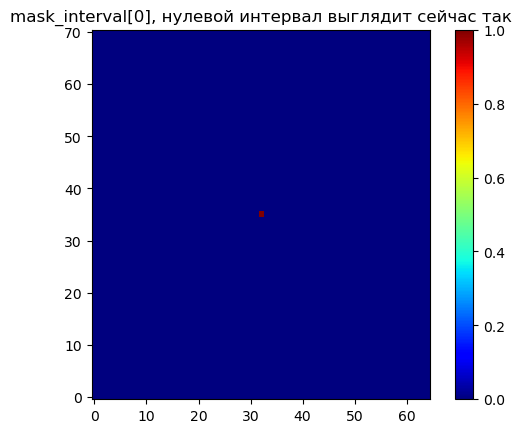

'mask_interval[0], нулевой интервал выглядит сейчас так'

In [281]:
display_grid(mask_interval[...,0], 'mask_interval[0], нулевой интервал выглядит сейчас так')

In [282]:
pairs_list = []

for k in range(len(theta_mesh)):  # для индексов 0..10
    interval_indxs_2D = np.where(mask_interval[..., k] == 1)
    pairs_list_unique = list(zip(interval_indxs_2D[0], interval_indxs_2D[1]))
    pairs_list.append(pairs_list_unique)

где-то здесь надо объединить интервалы после восьмого


In [256]:
#mean_PSS_corners = (theta_mesh[10] + theta_mesh[11] + theta_mesh[12] + theta_mesh[13] )/ 4
#for interval_number in range(10, len(theta_mesh)):
#    size_system = len(pairs_list[interval_number])
#    Matrix = np.zeros((size_system, size_system))
#    pairs = pairs_list[interval_number]
#    for indx in range(size_system):
#        two_d = pairs[indx]
#        i, j = two_d
#        theta_discret[two_d] = mean_PSS_corners

In [283]:
# Оптимизированная версия создания tau_mesh2
# Создаем маску для значений, которые не являются NaN
valid_mask = ~np.isnan(theta_discret)

# Получаем уникальные значения из theta, где theta_discret не NaN
mesh2 = np.unique(theta_discret[valid_mask])

# Сортируем значения
mesh2.sort()

# Преобразуем в numpy массив
theta_mesh = np.array(mesh2)

mask_interval = np.zeros((N+1, M+1, len(theta_mesh)))  # Создаём 3D-массив
for i in range(len(theta_mesh)):
    mask_interval[..., i] = theta_discret == theta_mesh[i] 

pairs_list = []

for k in range(len(theta_mesh)):  # для индексов 0..10
    interval_indxs_2D = np.where(mask_interval[..., k] == 1)
    pairs_list_unique = list(zip(interval_indxs_2D[0], interval_indxs_2D[1]))
    pairs_list.append(pairs_list_unique)

print(len(theta_mesh))
print(theta_mesh)

13
[282129.30722061 282129.30723783 282129.3072408  282129.30724226
 282129.30724318 282129.30724378 282129.30724428 282129.30724475
 282129.30724537 282129.30724631 282129.30724778 282129.30725059
 282129.30725609]


начало конца. составляю набор систем для апскейлинга

In [284]:
heff_noNaN = heff
perm_noNaN = perm


теперь можно пробовать делать системы для отдельно взятых интервалов. количество систем пугает, конечно.

In [285]:
pressure_masked = np.zeros_like(poro)
pressure_masked.fill(np.nan)


общий большой цикл по интервалам. и это только для вычисления нового поля давления для пересчёта $T^-$


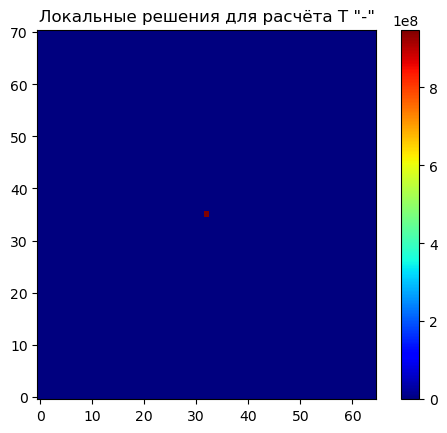

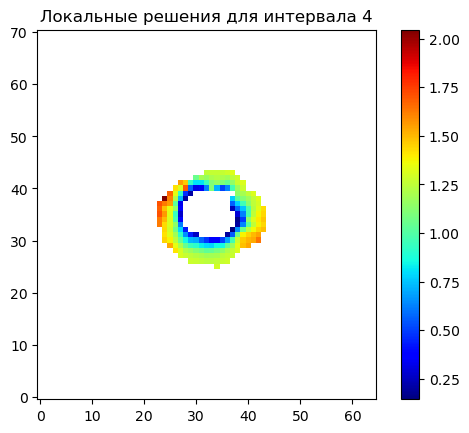

'Локальные решения для интервала 4'

In [286]:
pressure_new = np.zeros_like(poro)
for interval_number in range(1, len(theta_mesh)):
    size_system = len(pairs_list[interval_number])
    Matrix = np.zeros((size_system, size_system))
    pairs = pairs_list[interval_number]
    for indx in range(size_system):
        two_d = pairs[indx]
        i, j = two_d
        coeffs = np.zeros(4)
        if i>0:
            left_idx = (i-1, j)
            if theta_discret[left_idx] == theta_discret[two_d]:
                coeffs[0] = cDarcy * (heff_noNaN[left_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[left_idx]) + (1/perm_noNaN[two_d]))
                l_column = pairs.index(left_idx)
                Matrix[indx][l_column] = - coeffs[0]
            elif theta_discret[left_idx] < theta_discret[two_d]:
                coeffs[0] = 2 * cDarcy * (heff_noNaN[left_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[left_idx]) + (1/perm_noNaN[two_d]))
        if i<np.shape(poro)[0]-1:
            right_idx = (i+1, j)
            if theta_discret[right_idx] == theta_discret[two_d]:
                coeffs[1] = cDarcy * (heff_noNaN[right_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[right_idx]) + (1/perm_noNaN[two_d]))
                l_column = pairs.index(right_idx)
                Matrix[indx][l_column] = - coeffs[1]
            elif theta_discret[right_idx] < theta_discret[two_d]:
                coeffs[1] = 2 * cDarcy * (heff_noNaN[right_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[right_idx]) + (1/perm_noNaN[two_d]))
        if j>0:
            top_idx = (i, j-1)
            if theta_discret[top_idx] == theta_discret[two_d]:
                coeffs[2] = cDarcy * (heff_noNaN[top_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[top_idx]) + (1/perm_noNaN[two_d]))
                l_column = pairs.index(top_idx)
                Matrix[indx][l_column] = - coeffs[2]
            elif theta_discret[top_idx] < theta_discret[two_d]:
                coeffs[2] = 2 * cDarcy * (heff_noNaN[top_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[top_idx]) + (1/perm_noNaN[two_d]))
        if j<np.shape(poro)[1]-1:
            bot_idx = (i, j+1)
            if theta_discret[bot_idx] == theta_discret[two_d]:
                coeffs[3] = cDarcy * (heff_noNaN[bot_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[bot_idx]) + (1/perm_noNaN[two_d]))
                l_column = pairs.index(bot_idx)
                Matrix[indx][l_column] = - coeffs[3]
            elif theta_discret[bot_idx] < theta_discret[two_d]:
                coeffs[3] = 2 * cDarcy * (heff_noNaN[bot_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[bot_idx]) + (1/perm_noNaN[two_d]))
        Matrix[indx][indx] = np.sum(coeffs)
        if np.sum(coeffs) == 0:
            print(indx, two_d, left_idx, right_idx, top_idx, bot_idx)
            print('Эфф. толщина в ячейках с нулевой строкой')
            print(heff[two_d], heff[left_idx], heff[right_idx], heff[top_idx], heff[left_idx])
            print('Проницаемость в ячейках с нулевой строкой')
            print(perm[two_d], perm[left_idx], perm[right_idx], perm[top_idx], perm[left_idx])
    b = np.zeros(size_system)
    for indx in range(size_system):
        two_d = pairs[indx]
        b[indx] = heff[two_d] * poro[two_d] * dx * dx 

    x = solve(Matrix, b)
    #print(np.mean(x))
    
    for indx in range(size_system):
        two_d = pairs[indx]
        pressure_new[two_d] = x[indx]
    #display_grid(pressure_new, 'давления на шаге ' + str(interval_number))
        if interval_number == 2:
            pressure_masked[two_d] = x[indx]
pressure_new[I_well][J_well] = heff[I_well][J_well] * poro[I_well][J_well] * dx * dx / Well_Index 
display_grid(pressure_new, 'Локальные решения для расчёта Т "-"')
display_grid(pressure_masked, 'Локальные решения для интервала 4')

таким образом, получено поле давления для дальнейшего вычисления $\Delta p^{pss}$ и $q_f$ но только для $T^-$! 

нужно для каждого интервала посчитать своё опорное давление $\Delta p^{PSS}$ и свой $q_f$

In [287]:
Heff = heff
poros = poro
permx = perm 
dx_1 = dx

In [295]:
q_f = np.zeros(len(theta_mesh))
for interval_number in range(0, len(theta_mesh)):
    size_system = len(pairs_list[interval_number])
    pairs = pairs_list[interval_number]
    for indx in range(size_system):
        two_d = pairs[indx]
        #i, j = two_d
        q_f[interval_number] += Heff[two_d] * poros[two_d] * dx_1 * dx_1 

In [296]:
print(len(q_f))

13


$$\Delta p^{PSS} = \frac{\sum^{\text{NF}}_{n} \sum^{\text{ext}}_{m(n)} T_{nm} \cdot p_n }{\sum^{\text{NF}}_{n} \sum^{\text{ext}}_{m(n)} T_{nm}} $$
$NF$ $-$ no flow! итерация по ячейкам, контактирующим с непроточной границей

$ext$ $-$ external! проводимость вычисляется с соседями, находящимися за непроточной границей (внешними)

In [297]:
numerator = np.zeros(len(theta_mesh)) # числитель дроби
denominator = np.zeros_like(numerator) # знаменатель дроби
Delta_PSS = np.zeros_like(numerator)

for interval_number in range(0, len(theta_mesh)):
    size_system = len(pairs_list[interval_number])
    pairs = pairs_list[interval_number]

    for indx in range(size_system):
        two_d = pairs[indx]
        i, j = two_d
        coeffs = np.zeros(4)
        if i>0:
            left_idx = (i-1, j)
            if theta_discret[left_idx] > theta_discret[two_d]:
                coeffs[0] = cDarcy * (heff_noNaN[left_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[left_idx]) + (1/perm_noNaN[two_d]))
        elif i == 0:
            coeffs[0] = cDarcy * heff_noNaN[two_d] * perm_noNaN[two_d]
            

        if i<np.shape(poros)[0]-1:
            right_idx = (i+1, j)
            if theta_discret[right_idx] > theta_discret[two_d]:
                coeffs[1] = cDarcy * (heff_noNaN[right_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[right_idx]) + (1/perm_noNaN[two_d]))
        elif i == np.shape(poros)[0]-1:
            coeffs[1] = cDarcy * heff_noNaN[two_d] * perm_noNaN[two_d]

        if j>0:
            top_idx = (i, j-1)
            if theta_discret[top_idx] > theta_discret[two_d]:
                coeffs[2] = cDarcy * (heff_noNaN[top_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[top_idx]) + (1/perm_noNaN[two_d]))
        elif j == 0:
            coeffs[2] = cDarcy * heff_noNaN[two_d] * perm_noNaN[two_d]


        if j<np.shape(poros)[1]-1:
            bot_idx = (i, j+1)
            if theta_discret[bot_idx] > theta_discret[two_d]:
                coeffs[3] = cDarcy * (heff_noNaN[bot_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[bot_idx]) + (1/perm_noNaN[two_d]))
        elif j == np.shape(poros)[1]-1:
            coeffs[3] = cDarcy * heff_noNaN[two_d] * perm_noNaN[two_d]

        T_sum = 0
        T_sum = np.sum(coeffs)
        numerator[interval_number] += T_sum * pressure_new[two_d]
        denominator[interval_number] += T_sum
        
    Delta_PSS[interval_number] = numerator[interval_number] / denominator[interval_number]

print(len(Delta_PSS))

13


In [299]:
# это работает для первого интервала. не трогать. 

numerator = 0 # числитель дроби
denominator = 0 # знаменатель дроби

interval_number = 1
size_system = len(pairs_list[interval_number])
pairs = pairs_list[interval_number]


for indx in range(size_system):
        two_d = pairs[indx]
        i, j = two_d
        coeffs = np.zeros(4)
        if i>0:
            left_idx = (i-1, j)
            if theta_discret[left_idx] > theta_discret[two_d]:
                coeffs[0] = cDarcy * (heff_noNaN[left_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[left_idx]) + (1/perm_noNaN[two_d]))
                
        if i<np.shape(poros)[0]-1:
            right_idx = (i+1, j)
            if theta_discret[right_idx] > theta_discret[two_d]:
                coeffs[1] = cDarcy * (heff_noNaN[right_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[right_idx]) + (1/perm_noNaN[two_d]))

        if j>0:
            top_idx = (i, j-1)
            if theta_discret[top_idx] > theta_discret[two_d]:
                coeffs[2] = cDarcy * (heff_noNaN[top_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[top_idx]) + (1/perm_noNaN[two_d]))

        if j<np.shape(poros)[1]-1:
            bot_idx = (i, j+1)
            if theta_discret[bot_idx] > theta_discret[two_d]:
                coeffs[3] = cDarcy * (heff_noNaN[bot_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[bot_idx]) + (1/perm_noNaN[two_d]))
        T_sum = 0 
        T_sum = np.sum(coeffs)
        numerator += T_sum * pressure_new[two_d]
        denominator += T_sum 
delta_p_1 = numerator / denominator
print(numerator, denominator, delta_p_1)

9871255.110631134 3651590.061438715 2.7032758180807104


In [300]:
T_minus = q_f / Delta_PSS
T_minus

array([1.10763752e-05, 2.89180335e+05, 1.66059881e+06, 3.18955723e+06,
       3.76308928e+06, 6.17390026e+06, 4.97379583e+06, 5.12675780e+06,
       3.05204753e+06, 1.02986945e+06, 4.70313573e+05, 2.47535531e+05,
       7.68665675e+02])

для последнего интервала удалось (!) посчитать $\Delta p^{PSS}$ в теле общего цикла!!

теперь нужно перевернуть граничные условия и повторить тот же расчёт для $T^+$.

In [301]:
pressure_masked_plus = np.zeros_like(poros)
pressure_masked_plus.fill(np.nan)

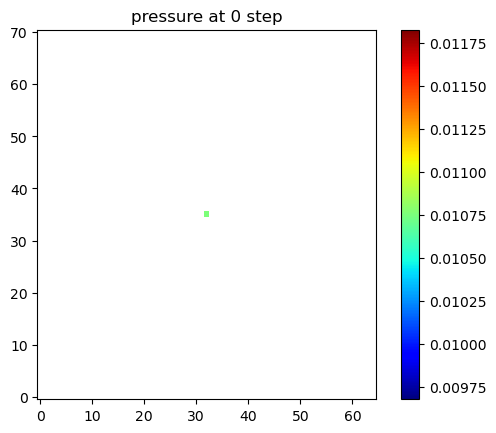

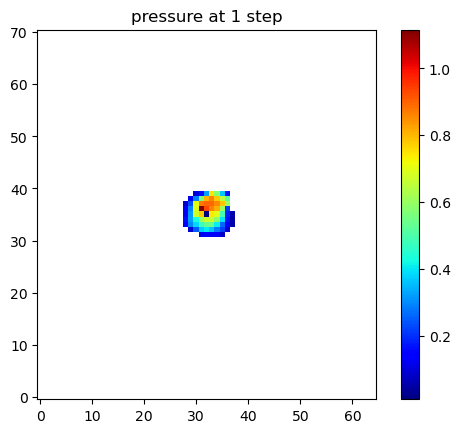

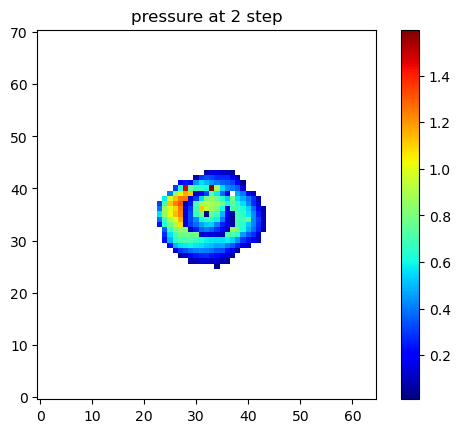

229 (39, 37) (38, 37) (40, 37) (39, 36) (39, 38)
Эфф. толщина в ячейках с нулевой строкой
56.395142 56.558472 56.22052 56.514587 56.558472
Проницаемость в ячейках с нулевой строкой
59.497047 38136.847417 489704.852609 189800.92756 38136.847417


LinAlgError: Matrix is singular.

In [302]:
pressure_new_plus = np.zeros_like(poros)
pressure_new_plus.fill(np.nan)

for interval_number in range(0, len(theta_mesh)):
    size_system = len(pairs_list[interval_number])
    Matrix = np.zeros((size_system, size_system))
    pairs = pairs_list[interval_number]
    for indx in range(size_system):
        two_d = pairs[indx]
        i, j = two_d
        coeffs = np.zeros(4)
        if i>0:
            left_idx = (i-1, j)
            if theta_discret[left_idx] == theta_discret[two_d]:
                coeffs[0] = cDarcy * (heff_noNaN[left_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[left_idx]) + (1/perm_noNaN[two_d]))
                l_column = pairs.index(left_idx)
                Matrix[indx][l_column] = - coeffs[0]
            elif theta_discret[left_idx] > theta_discret[two_d]:
                coeffs[0] = 2 * cDarcy * (heff_noNaN[left_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[left_idx]) + (1/perm_noNaN[two_d]))
        elif i == 0:
            coeffs[0] = 2 * cDarcy * (heff_noNaN[two_d] + heff_noNaN[two_d]) / ((1/perm_noNaN[two_d]) + (1/perm_noNaN[two_d]))

        if i<np.shape(poros)[0]-1:
            right_idx = (i+1, j)
            if theta_discret[right_idx] == theta_discret[two_d]:
                coeffs[1] = cDarcy * (heff_noNaN[right_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[right_idx]) + (1/perm_noNaN[two_d]))
                l_column = pairs.index(right_idx)
                Matrix[indx][l_column] = - coeffs[1]
            elif theta_discret[right_idx] > theta_discret[two_d]:
                coeffs[1] = 2 * cDarcy * (heff_noNaN[right_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[right_idx]) + (1/perm_noNaN[two_d]))
        
        elif i == np.shape(poros)[0]-1:
            coeffs[1] = 2 * cDarcy * (heff_noNaN[two_d] + heff_noNaN[two_d]) / ((1/perm_noNaN[two_d]) + (1/perm_noNaN[two_d]))
        
        
        if j>0:
            top_idx = (i, j-1)
            if theta_discret[top_idx] == theta_discret[two_d]:
                coeffs[2] = cDarcy * (heff_noNaN[top_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[top_idx]) + (1/perm_noNaN[two_d]))
                l_column = pairs.index(top_idx)
                Matrix[indx][l_column] = - coeffs[2]
            elif theta_discret[top_idx] > theta_discret[two_d]:
                coeffs[2] = 2 * cDarcy * (heff_noNaN[top_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[top_idx]) + (1/perm_noNaN[two_d]))
        elif j == 0:
           coeffs[2] = 2 * cDarcy * (heff_noNaN[two_d] + heff_noNaN[two_d]) / ((1/perm_noNaN[two_d]) + (1/perm_noNaN[two_d])) 
        
        if j<np.shape(poros)[1]-1:
            bot_idx = (i, j+1)
            if theta_discret[bot_idx] == theta_discret[two_d]:
                coeffs[3] = cDarcy * (heff_noNaN[bot_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[bot_idx]) + (1/perm_noNaN[two_d]))
                l_column = pairs.index(bot_idx)
                Matrix[indx][l_column] = - coeffs[3]
            elif theta_discret[bot_idx] > theta_discret[two_d]:
                coeffs[3] = 2 * cDarcy * (heff_noNaN[bot_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[bot_idx]) + (1/perm_noNaN[two_d]))
        elif j == np.shape(poros)[1]-1:
            coeffs[3] = 2 * cDarcy * (heff_noNaN[two_d] + heff_noNaN[two_d]) / ((1/perm_noNaN[two_d]) + (1/perm_noNaN[two_d]))



        Matrix[indx][indx] = np.sum(coeffs)
        if np.sum(coeffs) == 0:
            print(indx, two_d, left_idx, right_idx, top_idx, bot_idx)
            print('Эфф. толщина в ячейках с нулевой строкой')
            print(Heff[two_d], Heff[left_idx], Heff[right_idx], Heff[top_idx], Heff[left_idx])
            print('Проницаемость в ячейках с нулевой строкой')
            print(permx[two_d], permx[left_idx], permx[right_idx], permx[top_idx], permx[left_idx])
    b = np.zeros(size_system)
    for indx in range(size_system):
        two_d = pairs[indx]
        b[indx] = Heff[two_d] * poros[two_d] * dx_1 * dx_1 

    x = solve(Matrix, b)
    #print(np.mean(x))
    
    for indx in range(size_system):
        two_d = pairs[indx]
        pressure_new_plus[two_d] = x[indx]
        
        if interval_number == 2:
            pressure_masked_plus[two_d] = x[indx]
    display_grid(pressure_new_plus, 'pressure at ' + str(interval_number) + ' step')
#pressure_new_plus[I_well][J_well] = Heff[I_well][J_well] * poros[I_well][J_well] * dx_1 * dx_1 / Well_Index #надо подумать
display_grid(pressure_new_plus, 'Локальные решения для расчёта T "+"')
display_grid(pressure_masked_plus, 'Локальные решения для второго интервала')

ура! можно сделать вид что у меня снова всё получается

In [303]:
pressure_new_plus[I_well][J_well]

0.010753471711709702

In [304]:
q_f

array([  10500.69480563,  781734.205338  , 2213220.87462281,
       3683157.91640944, 5442138.24258469, 6666287.5499055 ,
       7854830.13786493, 7524062.73310337, 5963474.63101343,
       2970737.43474612, 1145650.7470595 ,  383918.17641737,
        212657.65746775])

In [305]:
numerator = np.zeros(len(theta_mesh)) # числитель дроби
denominator = np.zeros_like(numerator) # знаменатель дроби
Delta_PSS_plus = np.zeros_like(numerator)

for interval_number in range(1, len(theta_mesh)):
    size_system = len(pairs_list[interval_number])
    pairs = pairs_list[interval_number]

    for indx in range(size_system):
        two_d = pairs[indx]
        i, j = two_d
        coeffs = np.zeros(4)
        if i>0:
            left_idx = (i-1, j)
            if theta_discret[left_idx] < theta_discret[two_d]:
                coeffs[0] = cDarcy * (heff_noNaN[left_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[left_idx]) + (1/perm_noNaN[two_d]))
        elif i == 0:
            coeffs[0] = cDarcy * heff_noNaN[two_d] * perm_noNaN[two_d]
            

        if i<np.shape(poros)[0]-1:
            right_idx = (i+1, j)
            if theta_discret[right_idx] < theta_discret[two_d]:
                coeffs[1] = cDarcy * (heff_noNaN[right_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[right_idx]) + (1/perm_noNaN[two_d]))
        elif i == np.shape(poros)[0]-1:
            coeffs[1] = cDarcy * heff_noNaN[two_d] * perm_noNaN[two_d]

        if j>0:
            top_idx = (i, j-1)
            if theta_discret[top_idx] < theta_discret[two_d]:
                coeffs[2] = cDarcy * (heff_noNaN[top_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[top_idx]) + (1/perm_noNaN[two_d]))
        elif j == 0:
            coeffs[2] = cDarcy * heff_noNaN[two_d] * perm_noNaN[two_d]


        if j<np.shape(poros)[1]-1:
            bot_idx = (i, j+1)
            if theta_discret[bot_idx] < theta_discret[two_d]:
                coeffs[3] = cDarcy * (heff_noNaN[bot_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[bot_idx]) + (1/perm_noNaN[two_d]))
        elif j == np.shape(poros)[1]-1:
            coeffs[3] = cDarcy * heff_noNaN[two_d] * perm_noNaN[two_d]

        T_sum = 0
        T_sum = np.sum(coeffs)
        numerator[interval_number] += T_sum * pressure_new[two_d]
        denominator[interval_number] += T_sum
        
    Delta_PSS_plus[interval_number] = numerator[interval_number] / denominator[interval_number]

print(Delta_PSS_plus)

[0.00000000e+00 8.00552422e-01 3.03053676e-01 1.69326977e-01
 1.92164198e-01 3.26593382e-01 2.50296256e-01 4.39355830e-01
 7.56840269e-01 1.18769342e+00 5.73510679e-01 5.90892062e-01
 2.69994544e+02]


а какой поток должен быть в нулевой ячейке? по сути и по вкусу

In [306]:
Delta_PSS_plus[0] = Delta_PSS[0]
Delta_PSS_plus

array([9.48026280e+08, 8.00552422e-01, 3.03053676e-01, 1.69326977e-01,
       1.92164198e-01, 3.26593382e-01, 2.50296256e-01, 4.39355830e-01,
       7.56840269e-01, 1.18769342e+00, 5.73510679e-01, 5.90892062e-01,
       2.69994544e+02])

In [307]:
T_plus = q_f / Delta_PSS_plus 
T_plus

array([1.10763752e-05, 9.76493461e+05, 7.30306559e+06, 2.17517491e+07,
       2.83202505e+07, 2.04115819e+07, 3.13821320e+07, 1.71252143e+07,
       7.87943622e+06, 2.50126623e+06, 1.99761014e+06, 6.49726407e+05,
       7.87636871e+02])

по интуиции проводимость в ячейке скуважины должна быть либо 0 либо 1

падение давления на первом интервале.

In [308]:
q_inside = np.zeros_like(q_f)
for i in range(len(q_f)):
    for j in range(len(q_f)):
        if j < i+1:
            q_inside[i] += q_f[j]
q_inside[len(q_f)-1] == np.sum(q_f)


True

In [309]:
q_dmnless = np.zeros_like(q_f)
for i in range(len(q_f)):
    q_dmnless[i] = (np.sum(q_f) - q_inside[i])/(np.sum(q_f)-q_f[0])
q_dmnless

array([1.        , 0.98256687, 0.93321075, 0.85107416, 0.72971129,
       0.58104917, 0.40588185, 0.23809084, 0.10510186, 0.03885267,
       0.01330399, 0.00474239, 0.        ])

In [310]:
q_t = 3000 

заменила np.sum(q_f) на q_t

In [311]:
pss_drop_theta = np.zeros(len(q_f))
pss_drop_theta[1] = mu * q_t * (q_dmnless[0]/T_minus[1] + q_dmnless[1]/T_plus[1])
pss_drop_theta[1]

0.004185252578408399

In [312]:
pss_drop_theta[2] = mu * q_t *((q_dmnless[0]/T_minus[1] + q_dmnless[1]/T_plus[1]) + (q_dmnless[1]/T_minus[2] + q_dmnless[2]/T_plus[2]))
pss_drop_theta[2]

0.004859762957647899

In [313]:
pss_drop_theta[3] = mu * q_t *((q_dmnless[0]/T_minus[1] + q_dmnless[1]/T_plus[1]) + (q_dmnless[1]/T_minus[2] + q_dmnless[2]/T_plus[2]) + (q_dmnless[2]/T_minus[3] + q_dmnless[3]/T_plus[3]))
pss_drop_theta[3]

0.005170740954887182

In [314]:
mult = 0
for i in range(1,5):
    mult += (q_dmnless[i-1]/T_minus[i] + q_dmnless[i]/T_plus[i])
pss_drop_theta[4] = mult * mu * q_t
    

In [315]:
mult = 0
for i in range(1,6):
    mult += (q_dmnless[i-1]/T_minus[i] + q_dmnless[i]/T_plus[i])
pss_drop_theta[5] = mult * mu * q_t

In [316]:
mult = 0
for i in range(1,7):
    mult += (q_dmnless[i-1]/T_minus[i] + q_dmnless[i]/T_plus[i])
pss_drop_theta[6] = mult * mu * q_t

In [317]:
mult = 0
for i in range(1,8):
    mult += (q_dmnless[i-1]/T_minus[i] + q_dmnless[i]/T_plus[i])
pss_drop_theta[7] = mult * mu * q_t

In [318]:
mult = 0
for i in range(1,9):
    mult += (q_dmnless[i-1]/T_minus[i] + q_dmnless[i]/T_plus[i])
pss_drop_theta[8] = mult * mu * q_t

In [319]:
mult = 0
for i in range(1,10):
    mult += (q_dmnless[i-1]/T_minus[i] + q_dmnless[i]/T_plus[i])
pss_drop_theta[9] = mult * mu * q_t

In [320]:
mult = 0
for i in range(1,11):
    mult += (q_dmnless[i-1]/T_minus[i] + q_dmnless[i]/T_plus[i])
pss_drop_theta[10] = mult * mu * q_t

In [321]:
mult = 0
for i in range(1,12):
    mult += (q_dmnless[i-1]/T_minus[i] + q_dmnless[i]/T_plus[i])
pss_drop_theta[11] = mult * mu * q_t

In [322]:
mult = 0
for i in range(1,13):
    mult += (q_dmnless[i-1]/T_minus[i] + q_dmnless[i]/T_plus[i])
pss_drop_theta[12] = mult * mu * q_t

In [323]:
mult = 0
for i in range(1,14):
    mult += (q_dmnless[i-1]/T_minus[i] + q_dmnless[i]/T_plus[i])
pss_drop_theta[13] = mult * mu * q_t

IndexError: index 13 is out of bounds for axis 0 with size 13

In [129]:
mult = 0
for i in range(1,15):
    mult += (q_dmnless[i-1]/T_minus[i] + q_dmnless[i]/T_plus[i])
pss_drop_theta[14] = mult * mu * q_t

In [130]:
mult = 0
for i in range(1,16):
    mult += (q_dmnless[i-1]/T_minus[i] + q_dmnless[i]/T_plus[i])
pss_drop_theta[15] = mult * mu * q_t

In [324]:
print(pss_drop_theta)

[0.         0.00418525 0.00485976 0.00517074 0.00540693 0.00554442
 0.00566606 0.00575332 0.00583896 0.0059492  0.00603289 0.00609012
 0.01187415]


In [325]:
mu

0.3125

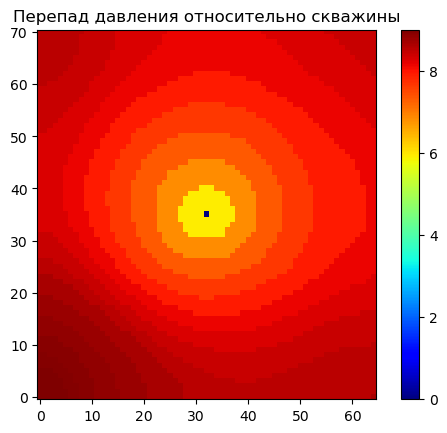

'Перепад давления относительно скважины'

In [133]:
visual = np.zeros_like(poros)
for interval_number in range(0, len(theta_mesh)):
    size_system = len(pairs_list[interval_number])
    Matrix = np.zeros((size_system, size_system))
    pairs = pairs_list[interval_number]
    for indx in range(size_system):
        two_d = pairs[indx]
        visual[two_d] = pss_drop_theta[interval_number]  

display_grid(visual, 'Перепад давления относительно скважины')

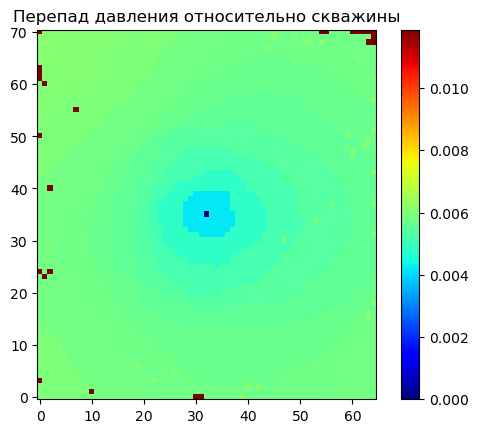

'Перепад давления относительно скважины'

In [326]:
visual = np.zeros_like(poros)
for interval_number in range(0, len(theta_mesh)):
    size_system = len(pairs_list[interval_number])
    Matrix = np.zeros((size_system, size_system))
    pairs = pairs_list[interval_number]
    for indx in range(size_system):
        two_d = pairs[indx]
        visual[two_d] = pss_drop_theta[interval_number]  

display_grid(visual, 'Перепад давления относительно скважины')

дальше смотреть профили давления через мат баланс?

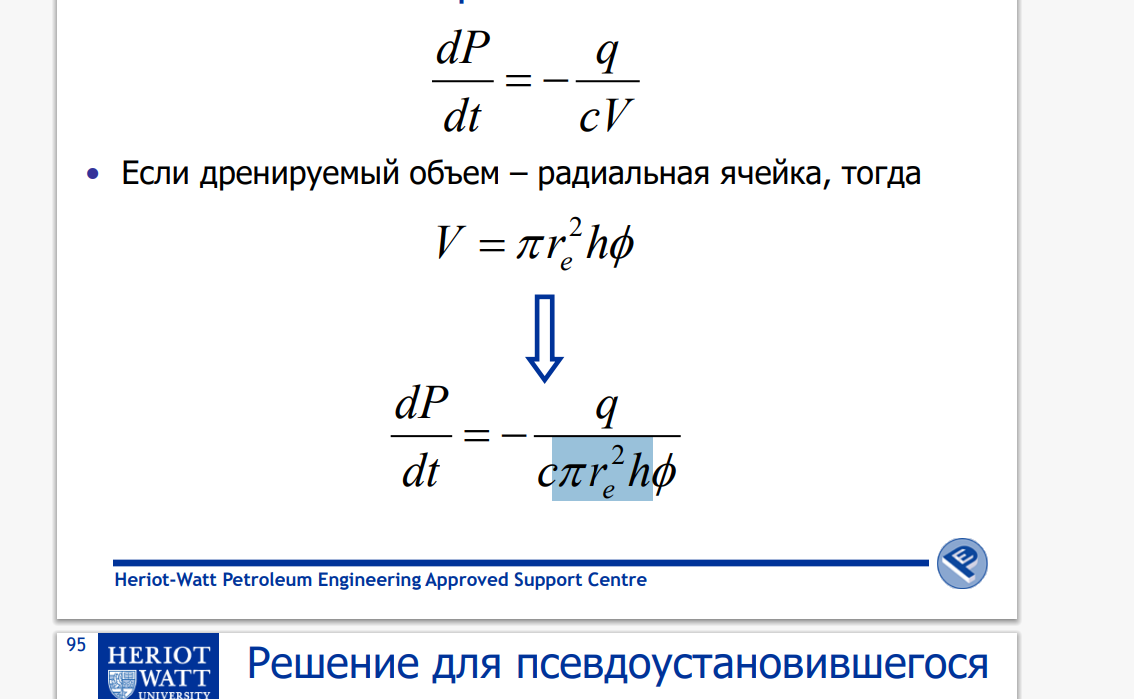

In [134]:
T = 730
Q = T*q_t # уже вряд ли накоп будет вот так считаться
# delP = - (q_t * T )/ (ct * V_res) + PInit # это с константой
delP = - (q_t * T )/ (ct * V_res) + P_Init_map # это когда начальное поле задано картой
# PInit можно задать полем и так учитывать гидростатику

In [135]:
delP

array([[213.46370226, 213.33977037, 213.2169829 , ..., 221.26443773,
        221.29474168, 221.32863145],
       [213.23994737, 213.10646349, 212.9834929 , ..., 221.23517137,
        221.25743394, 221.29362779],
       [213.01613145, 212.87434679, 212.75073534, ..., 221.21585374,
        221.24127489, 221.2791472 ],
       ...,
       [217.97868639, 217.58703905, 217.21069627, ..., 215.4522429 ,
        215.63241869, 215.82033067],
       [218.21287828, 217.81781297, 217.43471056, ..., 215.46399217,
        215.63943773, 215.82490831],
       [218.4495421 , 218.050067  , 217.6660338 , ..., 215.48221117,
        215.65172105, 215.83229356]])

In [136]:
V_res = np.sum(dx_1 * dx_1 * Heff * poros)

In [137]:
print(np.mean(visual), np.max(visual))

8.038099536538407 9.015146278220266


In [138]:
pss_vol_average = np.sum(dx_1 * dx_1 * Heff * poros * visual) / V_res
pss_vol_average

8.034724186703498

In [139]:
P_point = delP - (pss_vol_average - visual) 
for i,j in np.argwhere(visual):
    if P_point[i,j] > P_Init_map[i,j]:
        P_point[i,j] = P_Init_map[i,j]


In [140]:
# P_point = delP - (pss_vol_average - visual) 
# for i,j in np.argwhere(visual):
#     if P_point[i,j] > PInit:
#         P_point[i,j] = PInit
# 

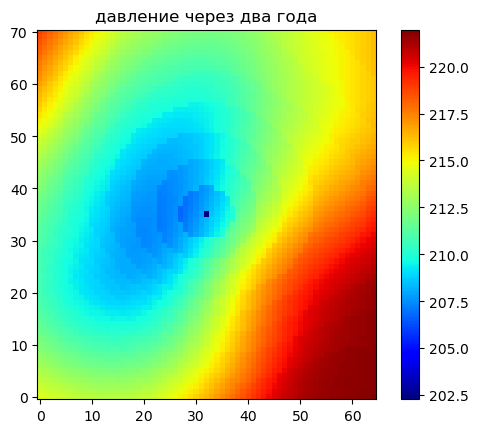

'давление через два года'

In [141]:
display_grid(P_point, 'давление через два года')

In [142]:
np.min(P_point) 

202.2855454514727

In [143]:
P_point[I_well,J_well]

202.2855454514727

In [144]:
print(I_well, J_well)
print(np.min(P_point))

35 32
202.2855454514727


In [145]:
#Параметры
DKeys = ["PRESSURE"]#Динамические свойства


s1 = 20 # Разбиение по x 
s2 = 26 # Разбиение по y
T = 301 # Разбиение по времени t 

pressure_tnav = np.zeros((s1,s2,T))


path = r"C:\Users\NovgorodovaAN\Documents\model\model\RESULTS\NEWBASECASE\result.UNRST"
t = 0
for kw, arr in resfo.read(path):
    if (DKeys[0] in str(kw)):
        pressure_tnav[:, :, t] = arr.astype(np.float32).reshape(s1, s2)
        t += 1
print(t)

NameError: name 'resfo' is not defined

In [ ]:
s1 = 20 # Разбиение по x 
s2 = 26 # Разбиение по y
TT = 301 # Разбиение по времени t 

pressure = np.zeros((s1,s2,TT))
pressure[..., 1].shape == P_point.shape
pressure_well_pss = np.zeros(TT)
pressure_well_tnav = np.zeros(TT)

In [ ]:
for t in range(0, TT):
    Q = t*q_t
    delP = - (q_t * t )/ (ct * V_res) + PInit
    #V_res = np.sum(dx_1 * dx_1 * Heff * poros)
    pss_vol_average = np.sum(dx_1 * dx_1 * Heff * poros * visual) / V_res
    P_point = delP - (pss_vol_average - visual) 
    for i,j in np.argwhere(visual):
        if P_point[i,j] > PInit:
            P_point[i,j] = PInit
    pressure[..., t] = P_point
    pressure_well_pss[t] = P_point[I_well, J_well]
    pressure_well_tnav[t] = pressure_tnav[I_well, J_well, t]


In [ ]:
pressure.shape

In [ ]:
display_grid(pressure[...,200], 'карта')

In [ ]:
plt.figure(figsize=(16, 6))
plt.plot(pressure_well_pss, 'o', markersize = 1.5, color = 'blue', label='PSS')
plt.plot(pressure_well_tnav, 's', markersize=1.5, color = 'red', label='tNav')
plt.xlabel('t')
plt.ylabel('P well')

ДОБАВЛЯЕМ СРАВНЕНИЕ С ТнАВИГАТОРОМ

In [ ]:
import resfo
import numpy as np

import scipy.io
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from mpl_toolkits.mplot3d import Axes3D
from IPython.display import HTML

In [ ]:
#Параметры
DKeys = ["PRESSURE"]#Динамические свойства


s1 = 20 # Разбиение по x 
s2 = 26 # Разбиение по y
T = 301 # Разбиение по времени t 

pressure_tnav = np.zeros((s1,s2,T))


path = r"C:\Users\NovgorodovaAN\Documents\model\model\RESULTS\NEWBASECASE\result.UNRST"
t = 0
for kw, arr in resfo.read(path):
    if (DKeys[0] in str(kw)):
        pressure_tnav[:, :, t] = arr.astype(np.float32).reshape(s1, s2)
        t += 1
print(t)

In [ ]:
P_initial = np.zeros_like(theta_mesh)
for i in range(0, len(theta_mesh)):
    P_initial[i] = PInit

In [ ]:
t = 2
unique_values_1 = np.zeros_like(theta_mesh)
for interval_number in range(0, len(theta_mesh)):
    pairs = pairs_list[interval_number]
    two_d = pairs[0]
    i,j = two_d
    unique_values_1[interval_number] = pressure[i,j,t]
unique_values_1

In [ ]:
t = 30
unique_values_2 = np.zeros_like(theta_mesh)
for interval_number in range(0, len(theta_mesh)):
    pairs = pairs_list[interval_number]
    two_d = pairs[0]
    i,j = two_d
    unique_values_2[interval_number] = pressure[i,j,t]
unique_values_2

In [ ]:
t = 50
unique_values_3 = np.zeros_like(theta_mesh)
for interval_number in range(0, len(theta_mesh)):
    pairs = pairs_list[interval_number]
    two_d = pairs[0]
    i,j = two_d
    unique_values_3[interval_number] = pressure[i,j,t]
unique_values_3

In [ ]:
kocherga_1 = P_initial - unique_values_1
kocherga_2 = P_initial - unique_values_2
kocherga_3 = P_initial - unique_values_3
x = pressure[I_well:poros.shape[0],J_well,t]
y = pressure_tnav[I_well:poros.shape[0], J_well, t]
plt.figure(figsize=(16, 6))
plt.plot(x, 'o--', markersize = 2.5, color = 'blue', label='PSS')
plt.plot(y, 'o--', markersize = 2.5, color = 'red', label='PSS')
#plt.plot(kocherga_3, 'o--', markersize = 2.5, color = 'blue', label='PSS')
#plt.plot(pressure_well_tnav, 's', markersize=1.5, color = 'red', label='tNav')
plt.xlabel('x')
plt.ylabel('P')

In [ ]:
t

In [ ]:
x = pressure[:,:,t].flatten()
y = pressure_tnav[:,:, t].flatten()
plt.figure(figsize=(16, 6))
plt.plot(x, 'o--', markersize = 2.5, color = 'blue', label='PSS')
plt.plot(y, 'o--', markersize = 2.5, color = 'red', label='tNav')
#plt.plot(kocherga_3, 'o--', markersize = 2.5, color = 'blue', label='PSS')
#plt.plot(pressure_well_tnav, 's', markersize=1.5, color = 'red', label='tNav')
plt.xlabel('N_cell')
plt.ylabel('P_flatten')

In [ ]:
t = 60
y = pressure_tnav[:, :, t].flatten()

x = pressure[:,:,t].flatten()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Ваши данные
y = pressure_tnav[:, :, t].flatten()
x = pressure[:,:,t].flatten()

plt.figure(figsize=(10, 8))
plt.scatter(x, y, alpha=0.7, s=5)
plt.xlabel('PSS')
plt.ylabel('tNav')
plt.title('Кросс-плот PSS vs tNav')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
unique_values = np.unique(pressure[..., 10])
print(unique_values)  # [1 2 3 4]

In [ ]:
#Анимация

#Данные из unrist файла
#Давление
press = pressure_tnav[..., 0]

vmax = np.max(pressure_tnav) 
vmin = np.min(pressure_tnav) 


fig = plt.figure(figsize=(7, 7))

#Создаем два графика для прогноза и численных результатов
ax1 = fig.add_subplot(111)
ax1.title.set_text('Давление')


#Отрисовываем в 0 момент времени
surf1 = ax1.imshow(press, cmap='jet', vmin=vmin, vmax=vmax,  extent=[0,2400,0,1800])


cax1 = fig.add_axes([ax1.get_position().x1+0.01,ax1.get_position().y0,0.02,ax1.get_position().height])
fig.colorbar(surf1, cax=cax1)


#Изменения данных
def update(num, pressure_tnav, surf1):
    press = pressure_tnav[...,num*30]

    # vmax = np.max(rPval) 
    # vmin = np.min(rPval) 

    
    # ax1.clear()
    
    ax1.title.set_text('Давление')
    
  #Отрисовываем в n момент времени
    surf1 = ax1.imshow(press, cmap='jet', vmin=vmin, vmax=vmax,  extent=[0,2400,0,1800])

    cax1.cla()
    fig.colorbar(surf1, cax=cax1)
    return surf1



anim = animation.FuncAnimation(fig, update, fargs=(pressure_tnav, surf1),  frames=11, interval=200, blit=False)#Тут формируется анимация
plt.close()
#plt.show()
HTML(anim.to_html5_video())

In [ ]:
#Анимация разности!!!!!
delta = pressure - pressure_tnav

#Данные из unrist файла
#Давление
press = delta[..., 0]

vmax = np.max(delta) 
vmin = np.min(delta) 


fig = plt.figure(figsize=(7, 7))

#Создаем два графика для прогноза и численных результатов
ax1 = fig.add_subplot(111)
ax1.title.set_text('Давление')


#Отрисовываем в 0 момент времени
surf1 = ax1.imshow(press, cmap='jet', vmin=vmin, vmax=vmax,  extent=[0,2400,0,1800])


cax1 = fig.add_axes([ax1.get_position().x1+0.01,ax1.get_position().y0,0.02,ax1.get_position().height])
fig.colorbar(surf1, cax=cax1)


#Изменения данных
def update(num, delta, surf1):
    press = delta[...,num*15]

    # vmax = np.max(rPval) 
    # vmin = np.min(rPval) 

    
    # ax1.clear()
    
    ax1.title.set_text('Давление')
    
  #Отрисовываем в n момент времени
    surf1 = ax1.imshow(press, cmap='jet', vmin=vmin, vmax=vmax,  extent=[0,2400,0,1800])

    cax1.cla()
    fig.colorbar(surf1, cax=cax1)
    return surf1



anim = animation.FuncAnimation(fig, update, fargs=(delta, surf1),  frames=21, interval=440, blit=False)#Тут формируется анимация
plt.close()
#plt.show()
HTML(anim.to_html5_video())

In [ ]:
#Анимация давления PSS!!!!

#Данные из unrist файла
#Давление
press = pressure[..., 0]

vmax = np.max(pressure) 
vmin = np.min(pressure) 


fig = plt.figure(figsize=(7, 7))

#Создаем два графика для прогноза и численных результатов
ax1 = fig.add_subplot(111)
ax1.title.set_text('Давление')


#Отрисовываем в 0 момент времени
surf1 = ax1.imshow(press, cmap='jet', vmin=vmin, vmax=vmax,  extent=[0,2400,0,1800])


cax1 = fig.add_axes([ax1.get_position().x1+0.01,ax1.get_position().y0,0.02,ax1.get_position().height])
fig.colorbar(surf1, cax=cax1)


#Изменения данных
def update(num, pressure, surf1):
    press = pressure[...,num*15]

    # vmax = np.max(rPval) 
    # vmin = np.min(rPval) 

    
    # ax1.clear()
    
    ax1.title.set_text('Давление')
    
  #Отрисовываем в n момент времени
    surf1 = ax1.imshow(press, cmap='jet', vmin=vmin, vmax=vmax,  extent=[0,2400,0,1800])

    cax1.cla()
    fig.colorbar(surf1, cax=cax1)
    return surf1



anim = animation.FuncAnimation(fig, update, fargs=(pressure, surf1),  frames=21, interval=440, blit=False)#Тут формируется анимация
plt.close()
#plt.show()
HTML(anim.to_html5_video())

In [ ]:
def display_grid(grid1, title1): # для отображения сеток
  #extent = 0, 40, 0, 40
  
  im=plt.imshow(grid1, cmap='jet')
  plt.colorbar(im)
 # plt.contour(grid1, levels = 40)
  
  plt.title(title1)
  plt.show()
  
  return title1

#контуры
def display_contour(grid1, title1): # для отображения сеток
  #im=plt.imshow(grid1, cmap='jet')

  plt.contour(np.transpose(grid1), levels = 100)
  #plt.colorbar(im)
  plt.title(title1)
  plt.gca().invert_yaxis()
  plt.show()
  return title1

# ОПТИМИЗИРОВАНО
# Вычисление объема дренирования по сетке DTOF 

def Vp(phi, dx, Heff, tau, tau_arg):   # объем дренирования
    if tau_arg == 0:
        return 0
    
    # Создаем маску для элементов, где tau <= tau_arg
    mask = tau <= tau_arg
    
    # Вычисляем сумму только для элементов, удовлетворяющих условию
    Vp_sum = np.sum(phi[mask] * Heff[mask] * dx * dx)
    
    return Vp_sum
 


#ОПТИМИЗИРОВАНО
def Vp_grid(phi, dx, Heff, tau, tau_arg):
    # Создаем маску для элементов, где tau <= tau_arg
    mask = tau <= tau_arg
    
    # Создаем результирующий массив и заполняем его значениями только там, где выполняется условие
    Vp_np_grid = np.zeros_like(tau)
    Vp_np_grid[mask] = phi[mask] * Heff[mask] * dx * dx
    
    return Vp_np_grid

#ОПТИМИЗИРОВАНО
def Vp_sm(tau_mesh, Vp_mesh1, tau_arg):   # сглаживание зависимости объема дренирования от tau для построения равномерной сетки по tau
    # Добавляем последние точки с небольшим смещением
    Vp_mesh1 = np.append(Vp_mesh1, Vp_mesh1[-1] + 0.0001)
    tau_mesh2 = np.append(tau_mesh, tau_mesh[-1] + 0.0001)
    
    # Находим индекс первого элемента, превышающего tau_arg
    i = np.searchsorted(tau_mesh2, tau_arg)
    
    # Вычисляем коэффициенты линейной интерполяции
    a = (Vp_mesh1[i-1] - Vp_mesh1[i]) / (tau_mesh2[i-1] - tau_mesh2[i])
    b = Vp_mesh1[i-1] - a * tau_mesh2[i-1]
    
    return a * tau_arg + b




#ОПТИМИЗИРОВАНО
def Wdi_sm(tau_mesh, tau_mesh_ravn, Vp_mesh, i):   # Wdi=dW/dtau *(1/W(tau))
    # Получаем значения tau для текущего и соседних узлов
    tau_prev = tau_mesh_ravn[i-1]
    tau_curr = tau_mesh_ravn[i]
    tau_next = tau_mesh_ravn[i+1]
    
    # Вычисляем значения Vp для всех трех точек
    Vp_prev = Vp_sm(tau_mesh, Vp_mesh, tau_prev)
    Vp_curr = Vp_sm(tau_mesh, Vp_mesh, tau_curr)
    Vp_next = Vp_sm(tau_mesh, Vp_mesh, tau_next)
    
    # Вычисляем разности tau
    dtau_prev = tau_curr - tau_prev
    dtau_next = tau_next - tau_curr
    
    # Вычисляем коэффициенты
    a = Vp_next / dtau_next
    b = (tau_next - tau_prev) * Vp_curr / (dtau_next * dtau_prev)
    c = Vp_prev / dtau_prev
    
    # Вычисляем Wdi
    Wdi1 = 2 * (a - b + c) / (Vp_next - Vp_prev)
    
    return Wdi1
    

    
#ОПТИМИЗИРОВАНО
def progon(a, b, c, psi):   # метод прогонки
    n = a.shape[0]
    
    # Инициализация массивов
    nu = np.zeros(n)
    lambda1 = np.zeros(n)
    delta = np.zeros(n)
    
    # Прямой ход
    nu[0] = -a[0] / b[0]
    lambda1[0] = psi[0] / a[0]
    
    # Векторизованный прямой ход
    for j in range(1, n):
        delta[j] = a[j] + c[j] * nu[j-1]
        nu[j] = -b[j] / delta[j]
        lambda1[j] = (psi[j] - c[j] * lambda1[j-1]) / delta[j]
    
    # Обратный ход
    P = np.zeros(n)
    P[-1] = lambda1[-1]
    
    # Векторизованный обратный ход
    for j in range(n-2, -1, -1):
        P[j] = nu[j] * P[j+1] + lambda1[j]
    
    return P

#ОПТИМИЗИРОВАНО
def P_solution_CTR_sm(permx, phi, dx, Heff, tau, tau_mesh, tau_mesh_init, rw, ct, mu, Bo, qw, P_Tn, Tn, Tn_1, Vp_mesh, Wdi_ravn, I_well, J_well):  # Вычисление куба давления на шаге n+1
    # Вычисление tau_w
    tau_w = rw * np.sqrt(phi[I_well, J_well] * ct * mu / (1e-15 * permx[I_well, J_well]))
    tau_mesh[0] = tau_w
    
    # Инициализация массивов
    n = tau_mesh.shape[0]
    a = np.zeros(n)
    b = np.zeros(n)
    c = np.zeros(n)
    psi = np.zeros(n)
    
    # Граничное условие 0
    W0 = Vp_sm(tau_mesh_init, Vp_mesh, tau_mesh[1]) / tau_mesh[1]
    a[0] = -1
    b[0] = 1
    c[0] = 0
    psi[0] = ((qw * Bo) / (24 * 3600)) * (tau_mesh[1] - tau_mesh[0]) / (ct * W0)
    
    # Вычисление коэффициентов трехдиагональной матрицы
    j = 1
    indd = False
    
    while j < n - 1:
        # Вычисление коэффициентов
        dtau_prev = tau_mesh[j] - tau_mesh[j-1]
        dtau_next = tau_mesh[j+1] - tau_mesh[j]
        dtau_total = tau_mesh[j+1] - tau_mesh[j-1]
        dt = Tn_1 - Tn
        
        a[j] = 1 + (2 * dt) / (dtau_next * dtau_prev)
        b[j] = -((Wdi_ravn[j] * dt) / dtau_total + 
                 (2 * dt) / (dtau_next * dtau_total))
        c[j] = (Wdi_ravn[j] * dt) / dtau_total - (2 * dt) / (dtau_prev * dtau_total)
        
        # Проверка условия диагонального преобладания
        if abs(a[j]) < abs(b[j]) + abs(c[j]):
            j = 1
            Tn_1 = Tn_1 - dt / 2
            indd = True
            print('gonevo')
        else:
            psi[j] = P_Tn[j] * 100000
            j += 1
    
    # Граничное условие N
    a[-1] = 1
    b[-1] = 0
    c[-1] = -1
    psi[-1] = 0
    
    # Решение СЛАУ методом прогонки
    PP = progon(a, b, c, psi)
    
    return PP / 100000, Tn_1, indd
   
#НЕ ОПТИМИЗИРОВАНО #Преобразование решения P(tau) в P(x,y)
def tau_to_XY(tau, tau_mesh, tau_mesh_init, P_tau, dtau, fault, I_well, J_well, tau_w):    
    #P_tau1=np.zeros(tau_mesh_init.shape[0])
   # j=0
   # while j<tau_mesh.shape[0]:
   #     P_tau1[j]=interp(tau_mesh, P_tau, tau_mesh_init[j])
   #     j=j+1
    tau_mesh[tau_mesh.shape[0]-1]=tau_mesh[tau_mesh.shape[0]-1]+dtau
    tau_mesh[0]=tau_mesh[0]-1
    PP=interpolate.interp1d(tau_mesh, P_tau)
    P_tau1=PP(tau_mesh_init)
    P_XY = np.random.uniform(0.0, 0.0, (N,M))
    P_XY=np.ma.MaskedArray(P_XY, fault)
    Ptau={}
    tau_mesh_init[0]=0
    i=0
    while i<=tau_mesh_init.shape[0]-1:
        Ptau[tau_mesh_init[i]]=P_tau1[i]
        i=i+1
    i=0
    while i<M:
     j=0
     while j<N:
       if fault[j,i]==False:   
         P_XY[j,i]=Ptau[tau.data[j,i]]
       j=j+1
     i=i+1
    #P_XY[I_well, J_well] = P_tau[0]     
    return P_XY  

def To_file(dx, Heff, rw, ct, mu, Bo, qw, S, PInit, dt, T_max, P_XY, TT, path_f, dtau): # Запись куба давления P(X,Y) в файл
    f = open(path_f+'/t='+str(TT/3600/24.0)+' day.txt', 'w')
    f.write('Boundary condition on well:  constant terminal rate (CTR)'+'\n')
    f.write('Boundary condition external:  seal boundary'+'\n')
    f.write('-------===========INPUT DATA:============-------------'+'\n')
    f.write('Permeability[mD]:  k_min='+str(np.amin(perm))+'             '+'k_average='+str(np.mean(perm))+'    k_max='+str(np.amax(perm))+ '\n')
    f.write('Porosity:          poro_min='+str(np.amin(poro))+'       '+'poro_average='+str(np.mean(poro))+'  poro_max='+str(np.amax(poro))+ '\n')
    f.write('viscousity[cp]:      mu='+str(Mu)+ '\n')
    f.write('formation volume factor:      Bo='+str(Bo)+ '\n')
    f.write('size of square domain[m]:  RR='+str(RR)+ '\n')
    f.write('well radius[m]:  rw='+str(rw)+ '\n')
    f.write('lateral gridblock size[m]:  dx='+str(dx)+ '\n')
    f.write('effective thickness[m]:  Heff_min='+str(np.amin(Heff))+'       '+'Heff_average='+str(np.mean(Heff))+'  Heff_max='+str(np.amax(Heff))+ '\n')
    f.write('oil rate[m3/day]:  qo='+str(qw)+ '\n')
    f.write('Skin-factor:  S='+str(S)+ '\n')
    f.write('Initial formation pressure[bar]:  Pres='+str(PInit)+ '\n')
    f.write('-------===========SOLVER PARAMETERS:============-------------'+'\n')
    f.write('time period[d]:'+str(T_max/3600/24.0)+'\n')
    f.write('time step[d]:'+str(dt/3600/24.0)+'\n')
    f.write('tau step:'+str(dtau)+'\n')
    f.write('formation pressure at t='+str(TT/3600/24.0)+'day'+'\n')
    f.write('X[m]     Y[m]   Pres[bar]'+'\n')
    
    i=0
    while i<M:
     j=0
     while j<N:
        f.write(str(j*dx)+'    '+str(i*dx)+'   '+str(P_XY[j,i])+'\n')
        j=j+1
     i=i+1        
    f.close()
    return TT 

def To_file_bhp(dx, Heff, rw, ct, mu, Bo, BHP, S, PInit, dt, T_max, P_XY, TT, path_f, dtau): # Запись куба давления P(X,Y) в файл
    f = open(path_f+'/t='+str(round(TT/3600/24.0,1))+' day.txt', 'w')
    f.write('Boundary condition on well:  constant terminal pressure (CTP)'+'\n')
    f.write('Boundary condition external:  seal boundary'+'\n')
    f.write('-------===========INPUT DATA:============-------------'+'\n')
    f.write('Permeability[mD]:  k_min='+str(np.amin(perm))+'             '+'k_average='+str(np.mean(perm))+'    k_max='+str(np.amax(perm))+ '\n')
    f.write('Porosity:          poro_min='+str(np.amin(poro))+'       '+'poro_average='+str(np.mean(poro))+'  poro_max='+str(np.amax(poro))+ '\n')
    f.write('viscousity[cp]:      mu='+str(Mu)+ '\n')
    f.write('formation volume factor:      Bo='+str(Bo)+ '\n')
    f.write('size of square domain[m]:  RR='+str(RR)+ '\n')
    f.write('well radius[m]:  rw='+str(rw)+ '\n')
    f.write('lateral gridblock size[m]:  dx='+str(dx)+ '\n')
    f.write('effective thickness[m]:  Heff_min='+str(np.amin(Heff))+'       '+'Heff_average='+str(np.mean(Heff))+'  Heff_max='+str(np.amax(Heff))+ '\n')
    f.write('Bottomhole pressure[bar]:  BHP='+str(BHP)+ '\n')
    f.write('Skin-factor:  S='+str(S)+ '\n')
    f.write('Initial formation pressure[bar]:  Pres='+str(PInit)+ '\n')
    f.write('-------===========SOLVER PARAMETERS:============-------------'+'\n')
    f.write('time period[d]:'+str(T_max/3600/24.0)+'\n')
    f.write('time step[d]:'+str(dt/3600/24.0)+'\n')
    f.write('tau step:'+str(dtau)+'\n')
    f.write('formation pressure at t='+str(TT/3600/24.0)+'day'+'\n')
    f.write('X[m]     Y[m]   Pres[bar]'+'\n')
    
    i=0
    while i<M:
     j=0
     while j<N:
        f.write(str(j*dx)+'    '+str(i*dx)+'   '+str(P_XY[j,i])+'\n')
        j=j+1
     i=i+1        
    f.close()
    return TT 


def CTP_Eik_method_sm(permx, phi, fault, dx, Heff, N_tau_mesh_ravn, I_well, J_well, rw, ct, mu, Bo, BHP, S, PInit, dt, T_max, path_f): #Вычисление и запись кубов давления на всех шагах
    # Инициализация тензора PyTorch для хранения полей давления
    N_time_steps = len(np.arange(0, T_max+2*dt, dt))
    tensor_dtof = torch.zeros((N_time_steps, N, M))
    
    # Задание геометрии источников
    phi1 = np.ones((N,M))
    phi1[I_well, J_well] = 0

    # Задание разлома/ границ коллектора
    phi1 = np.ma.MaskedArray(phi1, phi_mask)

    tau_w = rw * pow(phi[I_well, J_well]*ct*mu/(1e-15*permx[I_well, J_well]), 0.5)

    alpha = 1e-15*permx/(mu*poro*ct) # пьезопроводность
    speed = pow(alpha,0.5) # F(x)-уравнения Eikonal
    tau = skfmm.travel_time(phi1, speed, dx=dx) # вычисление сетки DTOF с помощью FMM
    display_grid(tau, 'tau')
    display_contour(tau, 'Контуры DTOF для месторождения Брюгге')
    
    Vp_grid1 = Vp_grid(phi, dx, Heff, tau, 20000)
    print('here CTP_Eik_method_sm')
    display_grid(Vp_grid1, 'Vp(tau=2000)')

    # построение сетки по tau (Исходная)
    tau_mesh2 = []  
    i = 0
    while i < tau.shape[0]:
        j = 0
        while j < tau.shape[1]:
            if (tau[i,j] != 'nan') and (tau[i,j] not in tau_mesh2) and (poro[i,j] > 0.001):
                tau_mesh2.append(tau[i,j])
            j = j + 1
        i = i + 1 
    tau_mesh2.sort()    
    tau_mesh_init = np.array(tau_mesh2) # сетка по tau (Исходная) 
    print(poro)

    # Вычисление объемов дренирования для исходной сетки tau
    ff = open(path_f+'/BHP_&_Q vs_time/Vp vs_tau.txt', 'w')
    Vp_mesh = []
    i = 0
    while i < tau_mesh_init.shape[0]:
        Vp_mesh.append(Vp(phi, dx_1, Heff, tau, tau_mesh_init[i]))  
        ff.write(str(tau_mesh_init[i])+'     '+str(Vp_mesh[i])+'\n')
        i = i + 1

    # построение сетки по tau (Равномерная)
    tau_mesh_ravn = []
    dtau = tau_mesh_init[tau_mesh_init.shape[0]-1]/(N_tau_mesh_ravn-1) # шаг сетки по tau

    i = 0
    while i < N_tau_mesh_ravn:
        tau_mesh_ravn.append(dtau*i)
        i = i + 1 
       
    tau_mesh = np.array(tau_mesh_ravn) # сетка по tau (Равномерная)   
 
    Wdi_ravn = []
    i = 0
    while i < N_tau_mesh_ravn-1:
        Wdi_ravn.append(Wdi_sm(tau_mesh_init, tau_mesh, Vp_mesh, i))
        i = i + 1
    Wdi_ravn1 = np.array(Wdi_ravn)

    Time_mesh = np.arange(0, T_max+2*dt, dt)
    P_Tn = np.random.uniform(PInit, PInit, tau_mesh.shape[0])    

    f = open(path_f+'/BHP_&_Q vs_time/BHP_&_Q vs_time.txt', 'w')
    f.write('Boundary condition on well:  constant terminal pressure (CTP)'+'\n')
    f.write('Boundary condition external:  seal boundary'+'\n')
    f.write('-------===========INPUT DATA:============-------------'+'\n')
    f.write('Permeability[mD]:  k_min='+str(np.amin(permx))+'             '+'k_average='+str(np.mean(permx))+'    k_max='+str(np.amax(permx))+ '\n')
    f.write('Porosity:          poro_min='+str(np.amin(phi))+'       '+'poro_average='+str(np.mean(phi))+'  poro_max='+str(np.amax(phi))+ '\n')
    f.write('viscousity[cp]:      mu='+str(Mu)+ '\n')
    f.write('formation volume factor:      Bo='+str(Bo)+ '\n')
    f.write('size of square domain[m]:  RR='+str(RR)+ '\n')
    f.write('well radius[m]:  rw='+str(rw)+ '\n')
    f.write('lateral gridblock size[m]:  dx='+str(dx)+ '\n')
    f.write('effective thickness[m]:  Heff_min='+str(np.amin(Heff))+'       '+'Heff_average='+str(np.mean(Heff))+'  Heff_max='+str(np.amax(Heff))+ '\n')
    f.write('Bottomhole pressure[bar]:  BHP='+str(BHP)+ '\n')
    f.write('Skin-factor:  S='+str(S)+ '\n')
    f.write('Initial formation pressure[bar]:  Pres='+str(PInit)+ '\n')
    f.write('-------===========SOLVER PARAMETERS:============-------------'+'\n')
    f.write('time period[d]:'+str(T_max/3600/24.0)+'\n')
    f.write('time step[d]:'+str(dt/3600/24.0)+'\n')
    f.write('tau step:'+str(dtau)+'\n')
    f.write('-------===========SOLUITION:============-------------'+'\n')
    f.write('time[day]              Q_oil[m3/day]              BHP[bar]              P_peacman'+'\n')
 
    Tn = 0
    Tn_1 = dt 
    q = {}
    ii = 1
    while Tn_1 < T_max+dt:
        WI = 2*math.pi*Heff[I_well,J_well]*1e-15*permx[I_well,J_well]/(mu*Bo*(math.log((0.2*dx)/rw)+S))  
        q[Tn/(3600*24)] = WI*(P_Tn[0]- BHP)*100000*24*3600 
        
        if Tn in Time_mesh:
            f.write(str(Tn/(3600*24))+'              '+str(q[Tn/(3600*24)])+'                '+str(BHP)+'                '+str(P_Tn[0])+'\n')
        res1 = P_solution_CTR_sm(permx, phi, dx, Heff, tau, tau_mesh, tau_mesh_init, rw, ct, mu, Bo, q[Tn/(3600*24)], P_Tn, Tn, Tn_1, Vp_mesh, Wdi_ravn1, I_well, J_well)
        P_Tn1 = res1[0]
        if res1[1] in Time_mesh: 
            P_XY = tau_to_XY(tau, tau_mesh, tau_mesh_init, P_Tn1, dtau, fault, I_well, J_well, tau_w)
            # Сохраняем поле давления в тензор
            tensor_dtof[ii] = torch.from_numpy(P_XY)
            res = To_file_bhp(dx, Heff, rw, ct, mu, Bo, BHP, S, PInit, dt, T_max, P_XY, Tn_1, path_f, dtau)
            ii = ii + 1
            Tn = Tn_1
            Tn_1 = Time_mesh[ii]
        else:
            Tn_1 = Time_mesh[ii] 
            Tn = res1[1]
        P_Tn = P_Tn1
            
    f.close()
    return q, P_XY, Tn, tensor_dtof  # Добавляем тензор в возвращаемые значения

def CTR_Eik_method_sm(permx, phi, fault, dx, Heff, N_tau_mesh_ravn, I_well, J_well, rw, ct, mu, Bo, qw, S, PInit, dt, T_max, path_f):
 # Инициализация тензора PyTorch для хранения полей давления
 N_time_steps = len(np.arange(0, T_max+2*dt, dt))
 tensor_dtof = torch.zeros((N_time_steps, N, M))  
 
 # Задание геометрии источников
 phi1 = np.ones((N,M))
 phi1[I_well, J_well]=0
 # Задание разлома
# разлом задаётся на местах, где проницаемость нулевая. а чем он тогда отличается от маски, которая обозначает границы месторождения?
 #mask = permx == 0

 phi1=np.ma.MaskedArray(phi1, phi_mask)

 tau_w=rw*pow(phi[I_well, J_well]*ct*mu/(1e-15*permx[I_well, J_well]), 0.5)

 alpha=1e-15*permx/(mu*poro*ct) # пьезопроводность
 speed=pow(alpha,0.5) # F(x)-уравнения Eikonal
 tau=skfmm.travel_time(phi1, speed, dx=dx) # вычисление сетки DTOF с помощью FMM
 display_grid(tau, 'DTOF')
 display_contour(tau, 'Contour DTOF')
 print(ct, mu)
 
 Vp_grid1=Vp_grid(phi,dx, Heff, tau, 20000)
 display_grid(Vp_grid1, 'Vp(tau)')
 # построение сетки по tau (Исходная)
 tau_mesh2=[]  
 i=0
 while i<tau.shape[0]:
    j=0
    while j<tau.shape[1]:
        #if tau[i,j] not in tau_mesh2:
        if (tau[i,j]!='nan')and(tau[i,j] not in tau_mesh2)and(permx[i,j]>0.001):
            tau_mesh2.append(tau[i,j])
        j=j+1
    i=i+1 
 tau_mesh2.sort()    
 tau_mesh_init=np.array(tau_mesh2) # сетка по tau (Исходная) 
 #print(tau_mesh_init)

#Вычисление объемов дренирования для исходной сетки tau
 ff = open(path_f+'/BHP_&_Q vs_time/Vp vs_tau.txt', 'w')
 Vp_mesh=[]
 i=0
 while i<tau_mesh_init.shape[0]:
   Vp_mesh.append(Vp(phi, dx_1, Heff, tau, tau_mesh_init[i]))  
   ff.write(str(tau_mesh_init[i])+'     '+str(Vp_mesh[i])+'\n')
   i=i+1

# построение сетки по tau (Равномерная)
 tau_mesh_ravn=[]

 dtau=tau_mesh_init[tau_mesh_init.shape[0]-1]/(N_tau_mesh_ravn-1) # шаг сетки по tau

 i=0
 while i<N_tau_mesh_ravn:
    tau_mesh_ravn.append(dtau*i)
    i=i+1 
   
 tau_mesh=np.array(tau_mesh_ravn) # сетка по tau (Равномерная)   
 
 Wdi_ravn=[]
 i=0
 while i<N_tau_mesh_ravn-1:
    Wdi_ravn.append(Wdi_sm(tau_mesh_init, tau_mesh, Vp_mesh, i))
    i=i+1
 Wdi_ravn1=np.array(Wdi_ravn)
    
 Time_mesh = np.arange(0, T_max+2*dt, dt)
 P_Tn= np.random.uniform(PInit, PInit, tau_mesh.shape[0])
 f = open(path_f+'/BHP_&_Q vs_time/BHP_&_Q vs_time.txt', 'w')
 f.write('Boundary condition on well:  constant terminal rate (CTR)'+'\n')
 f.write('Boundary condition external:  seal boundary'+'\n')
 f.write('-------===========INPUT DATA:============-------------'+'\n')
 f.write('Permeability[mD]:  k_min='+str(np.amin(permx))+'             '+'k_average='+str(np.mean(permx))+'    k_max='+str(np.amax(permx))+ '\n')
 f.write('Porosity:          poro_min='+str(np.amin(phi))+'       '+'poro_average='+str(np.mean(phi))+'  poro_max='+str(np.amax(phi))+ '\n')
 f.write('viscousity[cp]:      mu='+str(Mu)+ '\n')
 f.write('formation volume factor:      Bo='+str(Bo)+ '\n')
 f.write('size of square domain[m]:  RR='+str(RR)+ '\n')
 f.write('well radius[m]:  rw='+str(rw)+ '\n')
 f.write('lateral gridblock size[m]:  dx='+str(dx)+ '\n')
 f.write('effective thickness[m]:  Heff_min='+str(np.amin(Heff))+'       '+'Heff_average='+str(np.mean(Heff))+'  Heff_max='+str(np.amax(Heff))+ '\n')
 f.write('oil rate[m3/day]:  qo='+str(qw)+ '\n')
 f.write('Skin-factor:  S='+str(S)+ '\n')
 f.write('Initial formation pressure[bar]:  Pres='+str(PInit)+ '\n')
 f.write('-------===========SOLVER PARAMETERS:============-------------'+'\n')
 f.write('time period[d]:'+str(T_max/3600/24.0)+'\n')
 f.write('time step[d]:'+str(dt/3600/24.0)+'\n')
 f.write('tau step:'+str(dtau)+'\n')
 f.write('-------===========SOLUITION:============-------------'+'\n')
 f.write('time[day]              Q_oil[m3/day]              BHP[bar]              P_peacman'+'\n')
 Tn=0
 Tn_1=dt 
 BHP={}
 ii=1
 while Tn_1<T_max+dt:
    BHP[Tn/(3600*24)] = P_Tn[0]- (qw/(3600*24.0)*mu*Bo*(math.log((0.2*dx)/rw)+S))/(2*math.pi*Heff[I_well, J_well]*1e-15*permx[I_well, J_well])/100000 
    if Tn in Time_mesh:
       f.write(str(Tn/(3600*24))+'              '+str(qw)+'                '+str(BHP[Tn/(3600*24)])+'                '+str(P_Tn[0])+'\n')
    res1= P_solution_CTR_sm(permx, phi, dx, Heff, tau, tau_mesh, tau_mesh_init, rw, ct, mu, Bo, qw, P_Tn, Tn,Tn_1, Vp_mesh, Wdi_ravn1, I_well, J_well)
    P_Tn1=res1[0]
    if res1[1] in Time_mesh:
       P_XY = tau_to_XY(tau, tau_mesh, tau_mesh_init, P_Tn1, dtau, fault, I_well, J_well, tau_w)
    # Сохраняем поле давления в тензор
       tensor_dtof[ii] = torch.from_numpy(P_XY)
       res = To_file_bhp(dx, Heff, rw, ct, mu, Bo, BHP, S, PInit, dt, T_max, P_XY, Tn_1, path_f, dtau)
       ii = ii + 1
       Tn = Tn_1
       Tn_1 = Time_mesh[ii]
    else:
       Tn_1 = Time_mesh[ii] 
       Tn = res1[1]
    P_Tn = P_Tn1
  
 f.close()
 return BHP, P_XY, Tn, tensor_dtof    

def DTOF_method(permx, phi, fault, dx, Heff, N_tau_mesh_ravn, I_well, J_well, rw, ct, mu, Bo, CONTROL, S, PInit, dt, T_max, path_f):
   if CONTROL[0]=='BHP': 
       res=CTP_Eik_method_sm(permx, phi, fault, dx, Heff, N_tau_mesh_ravn, I_well, J_well, rw, ct, mu, Bo,  CONTROL[1], S, PInit, dt, T_max, path_f)
       print('here DTOF_method')
   else:
       res=CTR_Eik_method_sm(permx, phi, fault, dx, Heff, N_tau_mesh_ravn, I_well, J_well, rw, ct, mu, Bo,  CONTROL[1], S, PInit, dt, T_max, path_f)
       print('here DTOF_method')
         
   return res    

In [ ]:
import torch
poro = poros
import numpy as np
from Brugge_2Dmaps_for_DTOF.utilities import *

import pylab as plt
import math
import skfmm
import numpy as np
from scipy import interpolate
import time


start_time = time.time()

In [ ]:
#Ввод параметров пласта


(N,M) = np.shape(poros)
RN=2000
RR = RN
RM = 2600 #[м] размер расчетной области (длина стороны квадрата)
dx_1 =RN/N  #[м] шаг сетки попространству

Heff= np.random.uniform(10, 10, (N,M)) # ввод сетки эффективной мощности пласта

fault=np.zeros((N,M))

display_grid(poros, 'poro')
display_grid(permx, 'permx')

# ввод PVT данных
Mu=1 # viscousity [cp]
Ct =0.00013 # compress [1/bar]
Bo=1.2 # Объемный коэф.
#---------=====-------------
ct=Ct/100000 # compress [1/Pa]
mu=Mu/1000 # viscousity [Pa*sec]

phi_mask = np.zeros_like(poros)

rw=0.108 #[м] радиус скв.
qw=100 #[m3/day] дебит нефти
BHP=170 # [bar] 
S=0 #Скин-фактор
PInit=200 # [bar] Начальное пластовое давление
T_max=3600*24*30  # [сек] период расчета
dt=3600*24/4 # [сек] шаг по времени
path_f='C:/Work_2022/python_pr/res' # путь для записи результатов расчета

N_tau_mesh_ravn=100 #количество элементов в сетке по tau
I_well=int(N/2)-1 # Индекс по по горизонтали задающий положение скв.
J_well=int(M/2)-1 # Индекс по по горизонтали задающий положение скв.
#CONTROL=('BHP', BHP)

CONTROL=('Q', qw)
res=DTOF_method(permx, poros, fault, dx_1, Heff, N_tau_mesh_ravn, I_well, J_well, rw, ct, mu, Bo, CONTROL, S, PInit, dt, T_max, path_f)
     
display_grid(res[1], 'pressure at  '+str(res[2]/(3600*24))+' day with DTOF')

print('fin')

print("--- %s seconds ---" % (time.time() - start_time))

In [ ]:
display_grid(res[1], 'day2')